<span style="color: blue; font-size: 20px; font-weight: bold;">Комментарий ревьюера</span>

<span style="color: blue">Привет, Николай! Меня зовут Павел Григорьев, и я буду проверять этот проект.<br>Моя основная цель - не указать на совершённые тобой ошибки, а поделиться своим опытом и помочь тебе совершенствоваться как профессионалу.<br>Спасибо за проделанную работу! Предлагаю общаться на «ты».</span>
<details>
	<summary><u>Инструкция по организационным моментам (кликабельно)</u>⤵</summary>
<span style="color: blue">Я буду использовать различные цвета, чтобы было удобнее воспринимать мои комментарии:</span>


---


<span style="color: blue">синий текст - просто текст комментария</span>

<span style="color: green">✔️ и зеленый текст - все отлично</span>

<span style="color: orange">⚠️ и оранжевый текст - сделано все правильно, однако есть рекомендации, на что стоит обратить внимание</span>

<span style="color: red">❌ и красный текст - есть недочеты</span>


</details>    
</br>
<span style="color: blue">Пожалуйста, не удаляй мои комментарии в случае возврата работы, так будет проще разобраться, какие были недочеты, а также сразу увидеть исправленное.</span>

<span style="color: blue">Ответы на мои комментарии лучше тоже помечать.<br>
Например: </span><br><span style="color: purple; font-weight: bold">Комментарий студента</span>

<span style="color: blue; font-weight: bold;">Давай смотреть, что получилось!</span>

Привет, Павел!
Спасибо за подробное ревью!
Буду помечать свои комментарии так:

</span><br><span style="color: purple; font-weight: bold"> ✅ Комментарий студента № 1: some text</span>



<span style="color: blue; font-size: 18px; font-weight: bold;">Комментарий ревьюера 2</span>

<span style="color: blue">Привет еще раз. Спасибо, за исправления. Оформление комментариев по работе сохраняется. Только обозначим, что это вторая итерация.</span> 

# Предсказание отмены бронирований отелей

Управляющие сетью отелей UrbanStay поставили задачу разработать модель машинного обучения, которая будет предсказывать вероятность отмены бронирования комнат в отелях. Для бизнеса это важно с точки зрения снижения издержек и повышения загруженности отелей и, соответственно, для увеличения доходности.

## Содержание
1. <a href="#business_ml">Перевод бизнес-задачи на язык машинного обучения</a>
1. <a href="#libraries">Загрузка необходимых библиотек</a>
1. <a href="#data_prep">Этап 1: подготовка данных</a>
1. <a href="#modeling">Этап 2: моделирование</a>
1. <a href="#economics">Этап 3: расчёт экономической эффективности модели</a>
1. <a href="#conclusion">Этап 4: выводы по проекту</a>


<a id="business_ml"></a>

## Перевод бизнес-задачи на язык машинного обучения

На языке машинного обучения мы будем решать задачу классификации с двумя классами, при этом модель должна возвращать вероятность принадлежности к каждому классу:
- 0 - отмена не произошла, то есть осуществилось успешное заселение клиента
- 1 - отмена произошла

Решаемая задача представляет из себя задачу обучения с учителем, так как в исходных данных мы имеем целевую переменную.

Кроме числовых и категориальных признаков для обучения модели предлагается предварительно обработать таблицу с отзывами клиентов, так  как она содержит некатегориальные текстовые данные. Чтобы их использовать в обучении, применим один из механизмов векторизации для трансформации текста в числовой вектор для выделения новых признаков, помогающих по улучшить предсказание вероятности отказа от бронирования. Например, если пользователи будут отмечать шум или тишину в своих отзывах, то можно выделить признак level_of_noise, который будет показывать уровень шума, с которым столкнулся клиент при заселении в отель по брони.

В качестве моделей машинного обучения будем использовать CatBoost как хорошо зарекомендовавшую себя модель с хорошим базовым качеством и низкой склонностью к переобучению. Не ограничиваем свой выбор одной моделью, в ходе исследования будет принято решение о расширении набора алгоритмов машинного обучения в зависимости от качества результата.

Модель будет оцениваться на стандартных метриках классификации: Precision, Recall, F1-score в первую очередь и во вторую очередь на метриках финансовой значимости от внедрения модели.

К данным метрикам относятся:
- Incremental Revenue - прирост дохода благодаря модели
- Динамика отмен бронирования, вычисляемая как (доля_отмен_до - доля_отмен_после)/доля_отмен_до*100 %
- Динамика загрузки отелей.

Приемка модели осуществляется по следующим критериям:
- Доля отмен после внедрения модели — 10%.
- Загрузка отеля не должна уменьшиться больше чем на 8% после внедрения модели.
- Относительный IR должен составить не менее 50%.

<a id="libraries"></a>

## Загрузка необходимых библиотек

Осуществим установку необходимых библиотек и импорт используемых методов и классов.

#### Установка зависимостей

In [1]:
! rm requirements.txt
! python --version

Python 3.12.9


In [2]:
from pathlib import Path

requirements_file = Path('requirements.txt')
requirements = [
    'scikit-learn==1.6.1',
    'seaborn==0.13.2',
    'optuna==4.8.0',
    'humanfriendly==10.0',
    'phik==0.12.5',
    'xgboost==2.1.4', # 3.2.0
    'catboost==1.2.10',
    'lightgbm==4.6.0',
    'shap==0.49.1', # 0.51.0
    'python-dotenv==0.14.0',
    'psycopg2-binary==2.9.12', # 'psycopg2==2.9.12',
    'nltk==3.9.2', # 3.9.4
]
if not requirements_file.exists():
    with open(requirements_file, 'w') as f:
        f.write('\n'.join(requirements))
        print(f'{requirements_file} created')
else:
    print(f'{requirements_file} exists')

print('Установка зависимостей...')
!pip install -r requirements.txt
print('Зависимости успешно установлены!')


requirements.txt created
Установка зависимостей...

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Зависимости успешно установлены!


<span style="color: blue;: bold">Комментарий ревьюера : </span> ❌\
<span style="color: darkorange">Обрати внимание, некоторые пакеты конфликтуют с версией Питона на платформе.</span>

</span><br><span style="color: purple; font-weight: bold"> ✅ Комментарий студента № 1: исправлено</span>


<span style="color: blue; font-weight:">Комментарий ревьюера 2: </span> ✔️\
<span style="color: green"> 👍</span>

#### Импорт классов и методов

In [3]:
import os
import requests
import optuna
import time
import shap
import ast

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from phik import phik_matrix
from dotenv import load_dotenv
from sqlalchemy import create_engine


from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import lightgbm as lgb

from sklearn.calibration import CalibrationDisplay
from sklearn.model_selection import TimeSeriesSplit, KFold, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.isotonic import IsotonicRegression

from sklearn.model_selection import (
    cross_validate,
    cross_val_score,
)
from sklearn.metrics import (
    confusion_matrix,
    brier_score_loss,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    make_scorer,
)

import nltk # импортируем библиотеку nltk для обработки текста
nltk.download('stopwords') # скачиваем все существующие стоп-слова
from nltk.corpus import stopwords # импортируем стоп-слова


from humanfriendly import format_size


/Users/ngsmirnov/nikki/projects/practicum/module4_hotel_reservation_cancel_classif/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/ngsmirnov/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Хорошее оформление импортов! \
Импорты собраны в одной ячейке, разделены на функциональные группы пустой строкой.</font>

### Загрузка библиотеки классов SoloNeiroGood

Персональная библиотека для решения задач DS за авторством Smirnov Nikolai Georgievich (c) 2026-2027

In [4]:
TARGET_COL_NAME = 'booking_status'
RANDOM_STATE = 42
NAN_FLOAT = -999999.0
np.random.seed(RANDOM_STATE)

pd.set_option('display.max_columns', None) # выводить все колонки
pd.set_option('display.max_colwidth', 500) # выводить больше символов в ячейке


class DataBaseEnvConfig:
    """
    Класс для конфигурации подключения к БД через переменные окружения
    """
    def get_engine(self):
        load_dotenv()
        connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
            os.getenv('DB_USER'),
            os.getenv('DB_PASSWORD'),
            os.getenv('DB_HOST'),
            os.getenv('DB_PORT'),
            os.getenv('DB_NAME')
        )
        return create_engine(connection_string)


#### Заргузка ресурсов
class ResourceLoader:
    """
    Класс для безопасной загрузки ресурсов по http или с помощью подключения к БД.
    По http можно загружать как датасет в формате CSV, так и прозвольный файл.
    Если файл уже был скачан ранее и сохранен в локальной файловой системе, то
    загрузка из удаленного источника не производится.

    Для загрузки датасета: load_dataset(dataset_url, local_file, local_path='datasets'): dataframe
    Для загрузки файла: load_resource(resource_url, local_path, local_file): path
    """

    def __init__(self):
        pass

    def load_dataset_sql(self, table_name, local_path='datasets', query=None):
        """
        Загрузка датасета из БД по SQL запросу
        """
        local_dataset = f'{local_path}/{table_name}.csv'

        if os.path.exists(local_dataset):
            df = pd.read_csv(local_dataset)
            print(f'Датасет загружен из локального файла {local_dataset} без подключений к БД')
        else:
            if query is None:
                query = f'SELECT * FROM {table_name}'
            print(f'Загружаем датасет из БД по SQL запросу: {query[:30]}...')
            load_dotenv()
            df = pd.read_sql_query(query, con=DataBaseEnvConfig().get_engine())
            # сохраним датасет локально, чтобы не загружать из файла при рестарте ноутбука
            os.makedirs(local_path, exist_ok=True)
            df.to_csv(local_dataset, index=False)
            df = pd.read_csv(local_dataset)
            file_size = format_size(os.path.getsize(local_dataset))
            print(f'Датасет успешно загружен в {local_dataset},',
                  f'размер файла: {file_size}')
        return df

    def load_resource(self, resource_url, local_path, local_file):
        """
        Загрузка произвольного файла из сети и сохраение его локально.
        Если файл уже существует локально, то загрузка не происходит
        """
        local_resource_file = f'{local_path}/{local_file}'
        if os.path.exists(local_resource_file):
            print(f'Файл {local_resource_file} уже существует')
            return local_resource_file

        os.makedirs(local_path, exist_ok=True)
        print(f'Загружаем файл из {resource_url}')
        response = requests.get(resource_url)
        if response.status_code == 200:
            with open(local_resource_file, 'wb') as f:
                f.write(response.content)
            file_size = format_size(os.path.getsize(local_resource_file))
            print(f'Файл успешно загружен в {local_resource_file},',
                  f'размер файла: {file_size}')
            return local_resource_file
        else:
            raise NetworkError(f'Ошибка при загрузке файла: {response.status_code}')


    def load_dataset(
        self,
        dataset_url,
        local_file = None,
        local_path='datasets',
        sep=',',
        decimal='.'
    ):
        """
        Специальный. метод загрузки датасета по сети. Если датасет уже был скачан ранее и
        сохранен в локальной файловой системе, то загрузка не происходит.

        Parameters:
            dataset_url: str - url датасета
            local_file: str - имя файла, куда будет сохранен датасет (если None - будет вычислен из URL)
            local_path: str - путь к папке, куда будет сохранен датасет
            sep: str - разделитель в файле CSV
            decimal: str - символ, разделяющий целую часть от дробной в CSV

        Returns:
            df: pd.DataFrame - датасет
        """
        if local_file is None:
            local_file = dataset_url.split('/')[-1]
        local_dataset_file = f'{local_path}/{local_file}'
        remote_dataset_url = dataset_url
        def read_dataset_csv():
            return pd.read_csv(local_dataset_file, sep=sep, decimal=decimal)

        try:
            df = read_dataset_csv()
            print(f'Датасет успешно загружен из {local_dataset_file}')
        except FileNotFoundError:
            self.load_resource(remote_dataset_url, local_path, local_file)
            df = read_dataset_csv()

        print(f'Размер загруженного датасета: {df.shape[0]} строк, {df.shape[1]} столбцов', )
        return df

#### EDA
class CorrelationDisplayer:
    """
    Класс для отображения матрицы корреляций признаков в разных видах
    """
    def __init__(self, corr_matrix):
        self.corr_matrix = corr_matrix

    def get_corr_matrix(self):
        """
        Возвращает матрицу корреляций признаков, переданную в конструкторе
        """
        return self.corr_matrix

    def _subset_corr_matrix(self, subset):
        subset_cols = self.corr_matrix.columns if subset is None else subset
        return self.corr_matrix.loc[subset_cols, subset_cols]

    def draw_corr_matrix_full(
        self,
        digits=2,
        title='Матрица корреляций признаков',
        subtitle=None,
        figsize=(16, 10),
        subset=None,
    ):
        """
        Отображает полную матрицу корреляций признаков в виде heatmap

        Parameters:
            digits: int - количество знаков после запятой в значениях heatmap
            subset: [] - модмножество столбцов кор.матрицы для отображения
        """
        plt.subplots(figsize=figsize)
        matrix = self._subset_corr_matrix(subset)
        sns.heatmap(matrix.round(digits), annot=True, cmap='coolwarm', linewidths=0.5)
        plt.title(title + "\n" + subtitle if subtitle else title)
        plt.show()


    def draw_corr_matrix_with_target(
            self,
            target_col,
            title='Матрица корреляций с таргетом',
            subtitle=None,
            figsize=(16, 10),
    ):
        """
        Отображает матрицу корреляций признаков с таргетом в виде вертикального heatmap

        Parameters:
            target_col: str - название столбца таргета
            title: str - заголовок графика
            subtitle: str - подзаголовок графика
        """
        plt.subplots(figsize=figsize)
        data_heatmap = self.corr_matrix.loc[
            self.corr_matrix.index != target_col
        ][[target_col]].sort_values(by=target_col, ascending=False)
        sns.heatmap(data_heatmap, annot=True, cmap='coolwarm', linewidths=0.5)
        plt.title(title + "\n" + subtitle if subtitle else title)
        plt.show()

    def draw_pair_correlations(self, subset=None, figsize=(16, 10), corr_threshold=0.9):
        """
        Отображает попарные корреляции признаков в виде вертикального heatmap

        Parameters:
            subset: [] - модмножество столбцов кор.матрицы для отображения
            figsize: (int, int) - размер графика
            corr_threshold: float - порог корреляции, ниже которого корреляция не будет отображена
        """
        # преобразуем матрицу корреляции в датафрейм попарных корреляций
        # feature_1+feature_2 -> correlation
        matrix = self._subset_corr_matrix(subset)
        pair_correlations = matrix \
            .stack() \
            .reset_index() \
            .rename(columns={
                'level_0': 'feature1',
                'level_1': 'feature2',
                0: 'correlation'
            }) \
            .query('feature1 != feature2') \
            .sort_values(by='correlation', ascending=False) \

        def order_pair(row):
            if row['feature1'] > row['feature2']:
                return row['feature2'] + '/' + row['feature1']
            else:
                return row['feature1'] + '/' + row['feature2']

        pair_correlations['order_pair'] = pair_correlations.apply(order_pair, axis=1)
        pair_correlations = pair_correlations.drop(columns=['feature1', 'feature2'])
        pair_correlations = pair_correlations.drop_duplicates().reset_index(drop=True)
        pair_correlations = pair_correlations.query('correlation > @corr_threshold')
        pair_correlations = pair_correlations.sort_values(by='correlation')
        pair_correlations.plot(
            x='order_pair',
            y='correlation',
            xlabel='Значение корреляции',
            ylabel='Пара признаков',
            kind='barh',
            legend=False,
            figsize=figsize,
            grid=True,
        )
        plt.title('Попарные корреляции')
        plt.show()
        return pair_correlations.sort_values(by='correlation', ascending=False).reset_index(drop=True)

class EDAHelper:
    """
    Класс для выполнения Exploratory Data Analysis (EDA)
    """
    def __init__(self):
        pass

    def df_info(self, df, name = '', n_samples=3):
        """
        Выводит информацию о датасете:
        - количество строк и столбцов
        - размер датасета в памяти
        - первые, случайные и последние n_samples строк
        - информацию о типах данных столбцов
        - информацию о пропущенных значениях и проценте пропущенных значений в каждом столбце

        Parameters:
            df: pd.DataFrame - датафрейм
            name: str - произвольное название датасета
            n_samples: int - количество строк для вывода объектов датасета из начала, середины и конца
        """
        print('-'*50)
        print(f'Описание датасета {name}:')
        print(f'Датасет {name} содержит {df.shape[0]} строк и {df.shape[1]} столбцов.')
        print(f'Размер датасета {name} в памяти: {format_size(df.memory_usage().sum())}')
        print('-'*50)
        print(f'Данные датасета {name}:')
        print('-'*50)
        sample_df =  pd.concat([
            df.head(n_samples).assign(place='head'),
            df.sample(n_samples, random_state=RANDOM_STATE).assign(place='random'),
            df.tail(n_samples).assign(place='tail'),
        ]).sort_index()
        # move place column to first place
        last_col = sample_df.pop(sample_df.columns[-1])
        sample_df.insert(0, last_col.name, last_col)
        display(sample_df)
        print('-'*50)

        print(df.info())
        nan_counts = self.na_info(df)
        if (len(nan_counts) > 0):
            display(nan_counts)
        else:
            print(f'В датасете {name} нет пропущенных значений')

    def convert_to_datetime(self, df, column, format='%Y-%m-%d', print_time_range=True):
        """
        Преобразует столбец в датафрейме в дату и отображает временную ось данных в столбце
        Parameters:
            df: pd.DataFrame - датафрейм
            column: str - название столбца
            format: str - формат даты
            print_time_range: bool - выводить ли временной диапазон данных в столбце
        """
        df[column] = pd.to_datetime(df[column], format=format)
        if print_time_range:
            self.print_time_range(df, column)
        return df


    def print_time_range(self, df, datetime_column):
        """
        Выводит временную ось данных в столбце
        Parameters:
            df: pd.DataFrame - датафрейм
            datetime_column: str - название столбца
        """
        # определим временную ось таблицы:
        start_date = df[datetime_column].min()
        end_date = df[datetime_column].max()
        diff = int((end_date - start_date) / np.timedelta64(1, 'D'))
        diff_years = diff / 365.25

        print(f'Данные в "{datetime_column}" представлены за период {diff} дн. ({diff_years:.1f} л.): {start_date} - {end_date}')

    def box_hist(self, df, column, title=None, bins=20, hue=None, kde=True, stat='density'):
        """
        Выводит boxplot и histogramm для столбца датасета на одном графике
        Parameters:
            df: pd.DataFrame - датафрейм
            column: str - название столбца
            title: str - заголовок графика
            bins: int - количество бинов в гистограмме
            hue: str - название столбца для разбивки гистограммы по категориям
            kde: bool - рисовать ли kernel density estimation (плотность распределения)
            stat: str - тип значения для оси Y:
                - 'density' - плотность распределения
                - 'count' - количество объектов
                - 'frequency' - частота
                - 'percent' - доля в процентах от всего датасета
        """
        f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)})
        display(pd.DataFrame(df[[column]].describe().T))
        sns.boxplot(df[column], orient='h', ax=ax_box)
        sns.histplot(data=df, x=column, ax=ax_hist, bins=bins, hue=hue, kde=kde, stat=stat)

        f.suptitle(f'Распределение признака {column}' if title is None else title)
        if stat == 'density':
            ylabel = 'Плотность распределения'
        elif stat == 'count':
            ylabel = 'Количество'
        elif stat == 'frequecy':
            ylabel = 'Частота'
        else:
            ylabel = 'Доля'

        ax_box.set(xlabel='')
        ax_hist.set(
            xlabel=f'Значения признака {column}',
            ylabel=ylabel
        )
        plt.show()

    def time_line(self, df, datetime_column, y_column, ylabel=None, plot_kwargs={}):
        """
        Выводит значение признака y_column на временной оси datetime_column
        Parameters:
            df: pd.DataFrame - датафрейм
            datetime_column: str - название столбца со временной осью
            y_column: str - название столбца для отображения по оси Y
            ylabel: str - подпись оси Y
        """
        if ylabel is None:
            ylabel = y_column

        params = {
            'kind': 'line',
            'x': datetime_column,
            'y': y_column,
            'xlabel': 'Дата',
            'ylabel': ylabel,
            'title': f'Завимость признака "{y_column}" от времени',
            'legend': False,
        } | plot_kwargs
        df.plot(
            **params
        )
        plt.show()

    def drop_duplicates(self, df, subset=None):
        """
        Удаляет дубликаты из датасета и иценивает их количество и процент от датасета
        Parameters:
            df: pd.DataFrame - датафрейм
            subset: list - список столбцов, по которым проверять дубликаты
        """
        ndups = df.duplicated(subset=subset).sum()
        print(f'Найдено {ndups} дубликатов по {"всем" if subset is None else subset} столбцам')
        if ndups > 0:
            df_orig = df.copy()
            df.drop_duplicates(subset=subset, inplace=True)
            diff = len(df_orig) - len(df)
            diff_pct = diff / len(df_orig) * 100
            print(f'Удалено {diff} строк ({diff_pct:.1f}%) из {len(df_orig)}')
        else:
            print('Дубликатов не обнаружено')

    def na_info(self, df, round_digits=1):
        '''
        Возвращает таблицу с количеством и процентом пропусков в столбцах датасета.
        '''
        count_na_name = 'Количество пропусков'
        res = pd.DataFrame({
            'Количество строк': len(df),
            count_na_name: df.isna().sum(),
            'Процент пропусков': round(df.isna().mean()*100, round_digits)
        }).sort_values(by=count_na_name, ascending=False)
        return res.query(f'`{count_na_name}` > 0').reset_index()


    # Уникальные значения всех категориальных признаков
    def get_unique_values(self, df, top_n=5, cat_columns=[]):
        """
        Возвращает таблицу с уникальными значениями всех категориальных признаков.
        Parameters:
            df: pd.DataFrame - датафрейм
            top_n: int - количество значений для вывода высококардинальных столбцов
            cat_columns: list - список категориальных признаков, если не передан,
            то берутся все категориальные признаки с типом object
        """
        print('Уникальные значения всех категориальных признаков:\n')
        data = []
        columns = cat_columns if cat_columns else df.select_dtypes(include=['object']).columns
        for col in columns:
            unique_vals = df[col].unique().tolist()
            unique_vals.sort()
            top_n_vals = ', '.join(unique_vals[:top_n])
            unique_val_str =  top_n_vals if len(unique_vals) <= top_n else f'{top_n_vals}, ...'
            num_of_unique_vals = df[col].nunique()
            data.append({
                'feature': col,
                'num_of_unique_vals': num_of_unique_vals,
                'unique_vals': unique_val_str,
            })
        return pd.DataFrame(data)

### Обучение модели
class ModelTrainHelper:
    """
    Класс с утилитарными функциями для обучения и оценки качества модели МО
    """
    def __init__(self):
        self.best_estimator_ = None
        pass

    def do_cross_validation(
            self,
            pipelines,
            X_train_val, y_train_val,
            scoring,
            metrics_df_list = [],
            return_train_score=False,
            cv=5,
    ):
        """
        Выполняет обучение модели с помощью кросс-валидации.
        Parameters:
            pipelines: dict - словарь с конфигурациями моделей {model_name: {'model': model, 'fit_params': fit_params}}
            X_train_val: pd.DataFrame - тренировочная выборка
            y_train_val: pd.Series - тренировочный таргет
            scoring: list - список метрик для оценки качества модели (первая метрика - главная)
            metrics_df_list: list - внешний параметр для сохранения результатов в сводную таблицу
        """
        cv_results_by_model = {}
        # Обучение моделей
        for name, p in pipelines.items():
            start_time = time.time()
            cv_results = cross_validate(
                estimator=p['model'],
                X=X_train_val,
                y=y_train_val,
                scoring=scoring,
                return_train_score=return_train_score,
                return_estimator=True,
                cv=cv,
                verbose=0,
                n_jobs=-1,
                params=p.get('fit_params'),
            )
            end_time = time.time()
            wall_time = end_time - start_time
            print(f'Обучение "{name}" заняло {wall_time:.2f} секунд')
            cv_results['wall_time_sec'] = wall_time
            cv_results_by_model[name] = cv_results

        def non_negative_metric_(metric):
            """
            Утилитарная функция для определения положительной или отрицательной метрики и ее имени
            по приставке neg_ в названии метрики
            """
            if metric.startswith('neg_'):
                return (True, metric[len('_neg'):])
            else:
                return (False, metric)

        is_neg_main_metric, main_metric = non_negative_metric_(scoring[0])

        # Сохранение результатов в сводную таблицу:
        def append_metrics_(result_metrics, model_name, cv_results, test_or_train='test', scoring=[]):
            """
            Утилитарная функция для усреднения результатов метрики, полученной на кросс-валидации
            и сохранения ее в сводную таблицу
            """
            metrics_dict = {}

            metrics_dict['model_name'] = model_name
            metrics_dict['wall_time_sec'] = cv_results.get('wall_time_sec', 0)
            metrics_dict = metrics_dict | {
                metric: np.mean(cv_results[f'{test_or_train}_{metric}']) for metric in scoring
            }
            # for metric in scoring:
            #     print(metric, cv_results[f'{test_or_train}_{metric}'])
            # add standard deviation
            # metrics_dict = metrics_dict | {
            #     f'{metric}_std': np.std(-cv_results[f'{test_or_train}_{metric}']) for metric in scoring
            # }

            keys = list(metrics_dict.keys())
            for metric in keys:
                # invert sign for neg metrics like neg_mean_squared_error
                # and rename metrics withoud neg
                if metric.startswith('neg_'):
                    metrics_dict[metric[len('neg_'):]] = metrics_dict[metric] * -1 if not metric.endswith('_std') else 1
                    metrics_dict.pop(metric)

            result_metrics.append(metrics_dict)
            return metrics_dict

        for model_name, model_cv_results in cv_results_by_model.items():
            append_metrics_(
                metrics_df_list,
                model_name,
                model_cv_results,
                scoring=scoring,
            )
            if return_train_score and 'dummy' not in model_name.lower():
                append_metrics_(
                    metrics_df_list,
                    f'{model_name} (train)',
                    model_cv_results,
                    test_or_train='train',
                    scoring=scoring,
                )

        metrics_df = pd.DataFrame(metrics_df_list) \
            .sort_values(by=main_metric, ascending=is_neg_main_metric)

        metrics_df.set_index('model_name', inplace=True)
        return metrics_df.sort_index(axis=1)

    def confusion_matrix_displayed(self, y_true, y_pred, true_desc='Уйдет', false_desc='Останется'):
        """
        Визуализирует матрицу ошибок для бинарной классификации.
        y_true - истинные значения
        y_pred - предсказанные значения
        """
        cm = confusion_matrix(y_true, y_pred)

        # Визуализируем матрицу
        plt.figure(figsize=(8, 6))

        # Отображаем матрицу как изображение
        im = plt.imshow(cm, interpolation='nearest', cmap='Blues')
        plt.colorbar(im)

        # Добавляем подписи осей
        plt.xlabel('Предсказанные классы', fontsize=12)
        plt.ylabel('Истинные классы', fontsize=12)
        plt.title('Матрица ошибок', fontsize=14)

        # Настраиваем метки на осях
        tick_marks = [0, 1]
        plt.xticks(tick_marks, [false_desc, true_desc])
        plt.yticks(tick_marks, [false_desc, true_desc])

        # Матрица имеет структуру:
        matrix_desc = [
            ['TN', 'FP'],
            ['FN', 'TP'],
        ]

        # Добавляем числовые значения в ячейки
        for i in range(2):
            for j in range(2):
                plt.text(j, i, f'{matrix_desc[i][j]} {cm[i, j]}',
                        ha='center', va='center',
                        color='white' if cm[i, j] > cm.max()/2 else 'black',
                        fontsize=14)

        plt.tight_layout()
        plt.show()


        tn = cm[0, 0]
        fp = cm[0, 1]
        fn = cm[1, 0]
        tp = cm[1, 1]

        print('Расшифровка матрицы ошибок:')
        print(f'True Negatives (TN):  {tn} - правильно предсказали {false_desc}')
        print(f'False Positives (FP): {fp} - ошибочно предсказали {true_desc}')
        print(f'False Negatives (FN): {fn} - ошибочно предсказали {false_desc}')
        print(f'True Positives (TP):  {tp} - правильно предсказали {true_desc}')

    def feature_importance(self, model, feature_names):
        """
        Выводит важность признаков для линейной регрессии, строит bar plot важности.
        model - модель, для которой нужно вывести важность признаков
        feature_names - список названий признаков
        """
        # Получаем коэффициенты
        coefficients = model.coef_[0]
        intercept = model.intercept_[0]

        # DataFrame для анализа для удобства анализа коэффициентов
        coef_df = pd.DataFrame({
            'feature': feature_names,
            'coefficient': coefficients,
            'abs_coefficient': np.abs(coefficients)
        }).sort_values('abs_coefficient', ascending=False)

        # Визуализируем важность признаков:
        plt.figure(figsize=(8, 10))
        top_features = coef_df.sort_values(by='abs_coefficient', ascending=True)
        plt.barh(range(len(top_features)), top_features['coefficient'])
        plt.yticks(range(len(top_features)), top_features['feature'])
        plt.xlabel('Значение коэффициента')
        plt.title('Топ признаков по силе влияния на предсказание')
        plt.tight_layout()
        plt.show()

        return {
            'weights': coef_df.reset_index(drop=True),
            'intercept': intercept
        }

    def compare_metrics(self, baseline, enhanced, name, digits=3, pct_digits=0):
        """
        Сравнивает две метрики и выводит их разницу в процентах.
        baseline - базовая метрика
        enhanced - улучшенная метрика
        name - название метрики
        digits - количество знаков после запятой в числах
        pct_digits - количество знаков после запятой в процентах разницы
        """
        diff = enhanced - baseline
        diff_pct = diff / baseline * 100
        plus = '+' if diff > 0 else ''
        print(f'Улучшение метрики {name}:',
            f'{baseline:.{digits}f}->{enhanced:.{digits}f} ({plus}{diff_pct:.{pct_digits}f}%)')

class OptunaHelper:
    """
    Класс для оптимизации гиперпараметров с помощью Optuna.
    """
    def __init__(self, X, y, X_val=None, y_val=None, model_name='model'):
        self.X = X
        self.y = y
        self.X_val = X_val
        self.y_val = y_val
        self.model_name = model_name
        optuna.logging.set_verbosity(optuna.logging.WARNING)  # уменьшаем болтливость

    def fit_study(self, params_func, estimator_func, scorer_func=None, n_trials=30,
                  visualize=False, show_progress_bar=False, fit_score_func=None, cv=KFold(n_splits=5),
                  fit_params={}, fit_func=None, metrics_funcs={}):
        """
        Функция поиска оптимальных гиперпараметров.

        params_func - функция, возвращающая гиперпараметры для модели в формате Optuna
        estimator_func - функция, возвращающая модель с подготовленными гиперпараметрами
        scorer_func - функция, возвращающая метрику для оценки модели
        n_trials - число итераций
        visualize - флаг для визуализации результатов оптимизации
        show_progress_bar - флаг для вывода прогресса оптимизации
        fit_score_func - функция, осуществляющая вызов тренировки модели
        fit_func - функция, осуществляющая вызов тренировки модели
        metrics_funcs - словарь с функциями для вычисления метрик
        cv - объект кросс-валидации
        """

        def objective(trial):
            # описываем, какие гиперпараметры будем подбирать и в каких диапазонах.
            params = params_func(trial)

            # пайплайн с подготовкой данных и моделью
            # с подобранными на этой итерации гиперпараметрами
            pipeline = estimator_func(params)

            mean_score = 0
            if fit_score_func is not None:
                print('fit_score func was provided')
                mean_score = fit_score_func(pipeline, self.X, self.y, self.X_val, self.y_val, fit_params)
            elif isinstance(cv, KFold) or isinstance(cv, StratifiedKFold) or isinstance(cv, int):
                print('Using cross_val_score to optimize model')
                main_scores = cross_val_score(
                    pipeline,
                    self.X,
                    self.y,
                    cv=cv,
                    scoring=scorer_func,
                    n_jobs=-1
                )
            else:

                X = self.X
                y = self.y

                main_scores = []
                for fold, (train_index, valid_index) in enumerate(cv.split(X)):
                    # Разделение данных для текущего фолда
                    X_train, X_valid = X.iloc[train_index], X.iloc[valid_index],
                    y_train, y_valid = y.iloc[train_index], y.iloc[valid_index]

                    start_time = time.time()
                    if fit_func is not None:
                        X_valid_t = fit_func(pipeline, X_train, y_train, X_valid, y_valid, fit_params)
                        fit_time = time.time() - start_time
                        # Прогнозирование на уже трансформированных данных,
                        # чтобы не перезапускать pipeline (tfidf мог поменять словарь)
                        model = pipeline.named_steps['model']
                        score = scorer_func(model, X_valid_t, y_valid)
                    else:
                        pipeline.fit(X_train, y_train,
                                    eval_set=[(X_train, y_train), (X_valid, y_valid)],
                                    **fit_params)
                        fit_time = time.time() - start_time
                        score = scorer_func(pipeline, X_valid, y_valid)
                    main_scores.append(score)

                # Среднее значение метрики на кросс-валидации
                mean_score = np.mean(main_scores)

            # Сообщаем результат Optuna
            trial.report(mean_score, step=0)

            # Если результат плохой — прерываем итерацию
            if trial.should_prune():
                raise optuna.TrialPruned()

            # Возвращаем среднее значение метрики на кросс-валидации
            return mean_score

        # Фиксируем сид через семплер
        sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)

        study = optuna.create_study(
            direction='maximize',
            sampler=sampler,
        )

        study.optimize(
            objective,
            n_trials=n_trials, # число итераций
            show_progress_bar=show_progress_bar,
        )

        # Прогресс метрики по попыткам
        if (visualize):
            fig1 = optuna.visualization.plot_optimization_history(study)
            # Важность гиперпараметров
            fig2 = optuna.visualization.plot_param_importances(study)

            display(fig1)
            display(fig2)
        return study

class WallTime:
    """
    Класс для измерения времени выполнения кода.
    """
    def __init__(self):
        self.start_time = time.time()

    def elapsed_seconds(self):
        """
        Возвращает время в секундах, прошедшее с момента создания объекта.
        """
        return time.time() - self.start_time

class GridSearchHelper:
    """
    Класс для поиска оптимальных гиперпараметров с помощью GridSearchCV.
    """
    def __init__(self, X, y, scoring, cv):
        self.X = X
        self.y = y
        self.scoring = scoring
        self.main_metric = scoring[0]
        self.cv = cv
        self.last_results_top_ = None

    def fit_grid_(self, estimator, param_grid, model_name):
        print(f'Обучение модели {model_name} c перебором параметров...')
        grid = GridSearchCV(
            estimator=estimator,
            param_grid=param_grid,
            scoring=self.scoring,
            cv=self.cv,
            refit=self.main_metric,
            n_jobs=-1,
            verbose=0,
        )
        grid.fit(self.X, self.y)
        return grid

    def display_top_combinations_(self, grid_result, top_n=10):

        results_df = pd.DataFrame(grid_result.cv_results_) \
            .sort_values(by=f'mean_test_{self.main_metric}', ascending=False) \
            .reset_index(drop=True)

        print(f"\nТоп комбинаций по {self.main_metric}:")
        displayable_columns = [x for x in results_df.columns if x.startswith('mean_test_')]
        displayable_columns.insert(0, 'params')
        displayable_columns.append(f'std_test_{self.main_metric}')
        self.last_results_top_ = results_df[displayable_columns]
        display(self.last_results_top_.head(top_n))

    def fit_and_display_top(self, estimator, param_grid, model_name, top_n=5):
        """
        Подбор гиперпараметров и вывод топ комбинаций параметров и результатов

        estimator - модель
        param_grid - словарь с параметрами модели
        model_name - название модели
        top_n - количество лучших комбинаций параметров для вывода в итоговом датафрейме
        """
        grid_result = self.fit_grid_(estimator, param_grid, model_name)
        self.display_top_combinations_(grid_result, top_n=top_n)

        return grid_result

    def get_last_results_top(self):
        """
        Возвращает последние топ результатов поиска оптимальных гиперпараметров
        """
        return self.last_results_top_

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<font color='green'> Да, запрос не сложный )</font>

<font color='blue'><b>Комментарий ревьюера : </b></font> ⚠️\
<font color='darkorange'> В Pandas есть метод `pd.read_sql` в который можно передать или запрос или название таблицы если забирается вся таблица.</font>

<a id="data_prep"></a>

## Этап 1: подготовка данных

### Загрузка данных

- Все данные о работе сети отелей хранятся в базе данных на сервере. Загрузим данные через SQLAlchemy.

In [5]:
resource_loader = ResourceLoader()
df_bookings = resource_loader.load_dataset_sql('hotel_bookings')

Датасет загружен из локального файла datasets/hotel_bookings.csv без подключений к БД


In [6]:
df_reviews = resource_loader.load_dataset_sql('hotel_reviews')

Датасет загружен из локального файла datasets/hotel_reviews.csv без подключений к БД


Проведем экспресс-анализ загруженных данных:

In [7]:
eda_helper = EDAHelper()
eda_helper.df_info(df_bookings, 'Bookings')

--------------------------------------------------
Описание датасета Bookings:
Датасет Bookings содержит 35341 строк и 17 столбцов.
Размер датасета Bookings в памяти: 4.31 MB
--------------------------------------------------
Данные датасета Bookings:
--------------------------------------------------


,place,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests
0,head,INN00000,2020-07-08,корпоративное_бронирование,300,0,False,0,0,нет_отказа,6700.0,21,1,0,тип_питания_2,False,тип_1,0
1,head,INN00001,2021-09-19,корпоративное_бронирование,3,0,True,0,1,нет_отказа,62300.0,15,5,2,тип_питания_2,False,тип_1,1
2,head,INN00002,2022-11-19,корпоративное_бронирование,3,0,True,0,2,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,0
2858,random,INN02858,2021-02-17,офлайн_бронирование,1,0,True,1,2,отказ_брони,8900.0,209,1,0,тип_питания_1,False,тип_1,0
7123,random,INN07116,2019-05-09,офлайн_бронирование,3,0,False,2,0,нет_отказа,26800.0,150,4,0,тип_питания_1,False,тип_1,1
24193,random,INN24191,2020-09-08,онлайн_бронирование,3,2,False,1,0,отказ_брони,113900.0,89,13,4,тип_питания_1,False,тип_1,0
35338,tail,INN29068,2019-11-03,корпоративное_бронирование,2,2,False,0,0,нет_отказа,60300.0,109,7,2,тип_питания_1,False,тип_1,1
35339,tail,INN08545,2018-10-27,онлайн_бронирование,2,1,False,0,0,нет_отказа,0.0,126,12,4,тип_питания_1,False,тип_1,0
35340,tail,INN26845,2019-02-08,корпоративное_бронирование,2,0,False,0,0,нет_отказа,46900.0,122,5,2,не выбран,False,тип_1,0


--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 35341 entries, 0 to 35340
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   booking_id                 35341 non-null  str    
 1   booking_date               35341 non-null  str    
 2   sales_channel              35341 non-null  str    
 3   adult_count                35341 non-null  int64  
 4   child_count                35341 non-null  int64  
 5   returning_customer         35341 non-null  bool   
 6   previous_cancellations     35341 non-null  int64  
 7   previous_no_shows          35341 non-null  int64  
 8   booking_status             35341 non-null  str    
 9   booking_value              35341 non-null  float64
 10  days_until_checkin         35341 non-null  int64  
 11  weekday_nights             35341 non-null  int64  
 12  weekend_nights             35341 non-null  int64  
 13  meal_p

In [8]:
eda_helper = EDAHelper()
eda_helper.df_info(df_reviews, 'Reviewes')

--------------------------------------------------
Описание датасета Reviewes:
Датасет Reviewes содержит 25177 строк и 5 столбцов.
Размер датасета Reviewes в памяти: 1.01 MB
--------------------------------------------------
Данные датасета Reviewes:
--------------------------------------------------


,place,customer_id,booking_id,review_date,stay_rating,review_text
0,head,C0001,INN00000,2020-08-21,3,"Неплохо. тихо и спокойно, но отсутствие фена в номере. Кондиционер не справлялся, тяжело в номере"
1,head,C0001,INN00001,2021-10-15,3,"Неплохо. красивое оформление территории, но неработающий лифт."
2,head,C0001,INN00002,2023-03-08,4,Отличный отель! удобные парковочные места. здесь всегда ждут как родных
3706,random,C2748,INN05128,2021-03-02,3,"Неплохо. красивое оформление территории, но грубый персонал на ресепшн. Для детей ничего нет, им было скучно."
5508,random,C4115,INN07658,2020-01-16,3,"Неплохо. спа‑услуги на отлично, но не работает сейф в номере. Кондиционер не справлялся, тяжело в номере"
10727,random,C8037,INN15057,2019-01-21,4,"Отличный отель! удобные подушки и матрасы. отель в моём личном топе — 5/5 Летом есть кондиционер, спасал от жары."
25174,tail,C15588,INN29068,2020-03-19,3,"Неплохо. быстро заселили, но далеко до центра города. Для детей ничего нет, им было скучно."
25175,tail,C4596,INN08545,2019-03-26,5,Лучший отдых! Приеду ещё не раз. сервис выше всех похвал — вернусь! Дети в восторге от игровой зоны!
25176,tail,C14427,INN26845,2019-06-30,3,"Неплохо. тихо и спокойно, но плохое освещение. В номерах холодно. второго одеяла пришлось выпрашивать"


--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 25177 entries, 0 to 25176
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   customer_id  25177 non-null  str  
 1   booking_id   25177 non-null  str  
 2   review_date  25177 non-null  str  
 3   stay_rating  25177 non-null  int64
 4   review_text  25177 non-null  str  
dtypes: int64(1), str(4)
memory usage: 983.6 KB
None
В датасете Reviewes нет пропущенных значений


Данные из обеих таблиц загружены корректно. Сразу можно сказать, что пропущенных значений в таблицах нет. Загруженные объемы данных - 35к объектов в таблице бронирований, 25к - в таблице отзывов.

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'>Данные загружены корректно, первичный осмотр проведен.</font>

### Исследовательский анализ данных и предобработка

- Проведите EDA, используя один из следующих инструментов на ваш выбор:

    - библиотеку pandas;
    - SQL-запросы.
    
- EDA должен включать:
    - аналитическое исследование;
    - графическое исследование для количественных данных и для категориальных данных.

- Сделайте выводы о выбросах, пропусках, дубликатах и других аномалиях  в каждой таблице.
- Проведите необходимую предобработку данных.

Проведем исследование загруженных данных.

#### Таблица hotel_bookings



Таблица содержит следующие столбцы:

- `booking_id` — уникальный номер бронирования. Позволяет однозначно идентифицировать каждую бронь в системе. Пример: INN000001310.
- `booking_date` — дата оформления брони, например: 18.06.2018.
- `sales_channel` — способ оформления брони:
  - офлайн_бронирование — через телефон, ресепшен и др. без интернета;
  - онлайн_бронирование — через сайт или приложение;
  - корпоративное_бронирование — от лица компании или организации.
- `adult_count` — количество взрослых гостей в бронировании. Например, 2 означает двое взрослых (без учёта детей).
- `child_count` — количество детей в бронировании. Например, 0 — детей нет.
- `returning_customer` — признак, что клиент уже ранее бронировал: 1 — был, 0 — новый клиент.
- `previous_cancellations` — количество отменённых бронирований у клиента в прошлом. 0 — не отменял, 2 — отменял дважды.
- `previous_no_shows` — сколько раз клиент реально заселялся по брони: 1 — заселялся один раз, 0 — пока ни разу не заселялся.
- `booking_value` — итоговая стоимость бронирования в рублях.
- `days_until_checkin` — количество дней между датой бронирования и датой заезда. Например, 204 дня.
- `weekend_nights` — количество ночей в проживании, приходящихся на выходные (суббота, воскресенье). Пример: 4 ночи.
- `weekday_nights` — количество ночей в проживании, приходящихся на будни (понедельник-пятница). Пример: 2 ночи.
- `meal_plan` — выбранный тип питания. Пример: тип_питания_1, тип_питания_2.
- `parking_included` — информация о парковке: 0 — не бронировалась, 1 — парковка в броне.
- `room_type` — категория номера в бронировании. Пример: тип_1, тип_4.
- `customer_special_requests` — количество пожеланий и специальных запросов клиента (например, о дополнительной кровати, раннем заезде).
- `booking_status` — статус бронирования (целевая переменная):
  - отказ_брони — бронирование отменено;
  - нет_отказа — бронирование активно, не отменено.

Данные соответствуют описанию. 

Как было выяснено в предыдущем разделе пропусков в таблице бронирований нет. Оценим наличие дубликатов.

##### Дубликаты

In [9]:
eda_helper.drop_duplicates(df_bookings)

Найдено 4608 дубликатов по всем столбцам
Удалено 4608 строк (13.0%) из 35341


<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Отлично! Удалили явные дубликаты.</font>

In [10]:
df_bookings.shape

(30733, 17)

В таблице бронирований содержалось 13% дубликатов по всем 17 столбцам. Дублирующие данные были удалены так как негативно влияют на обучение, размер датасета теперь сотавляет 30к записей. Это все еще достаточно для дальнейшей работы.

In [11]:
df_bookings.duplicated(subset=['booking_id']).sum()

np.int64(0)

Дубликатов по идентификатору бронирования не обнаружено.

In [12]:
df_bookings.duplicated(subset=df_bookings.columns.to_list()[1:]).sum()

np.int64(0)

Дубликатов по остальным колонкам за вычетом booking_id не обнаружено.

##### Распределение числовых признаков

Исследуем распределения числовых столбцов

In [13]:
df_bookings.describe().T

,count,mean,std,min,25%,50%,75%,max
adult_count,30733.0,14.082387,48.832586,1.0,1.0,2.0,3.0,300.0
child_count,30733.0,0.356685,0.584576,0.0,0.0,0.0,1.0,2.0
previous_cancellations,30733.0,0.357303,0.629688,0.0,0.0,0.0,1.0,5.0
previous_no_shows,30733.0,0.839000,0.931910,0.0,0.0,1.0,1.0,5.0
booking_value,30733.0,61679.168347,42737.289170,0.0,33500.0,60300.0,80400.0,417221.2
days_until_checkin,30733.0,100.598770,71.933406,2.0,45.0,90.0,144.0,300.0
weekday_nights,30733.0,6.536687,3.336198,1.0,5.0,6.0,9.0,15.0
weekend_nights,30733.0,1.954772,1.476409,0.0,0.0,2.0,2.0,6.0
customer_special_requests,30733.0,0.620603,0.784428,0.0,0.0,0.0,1.0,5.0


- Есть явная проблема в столбце adult_count, так как максимальное значение неправдоподобно равно 300.
- В столбце booking_value (стоимость бронирования) есть выбросы - максимальное значение в 400к рублей и большое стандартное отклонение.
- Также есть выбросы в столбце days_until_checkin (дней от брони до заселения) - кто-то бронировал за 300 дней.
- Остальные столбцы не вызывают подозрений.

Исследуем проблемные столбцы:

Исследуем проблемные столбцы подробнее:

In [14]:
pd.DataFrame(df_bookings['adult_count'].value_counts()).reset_index()

,adult_count,count
0,1,11490
1,2,11272
2,3,5820
3,100,884
4,200,872
5,300,395


В столбце adult_count допущена явная ошибка ввода данных - в незначительном числе строк количество проживающих увеличено в 100 раз. Требуется привести данные к ожидаемому виду:

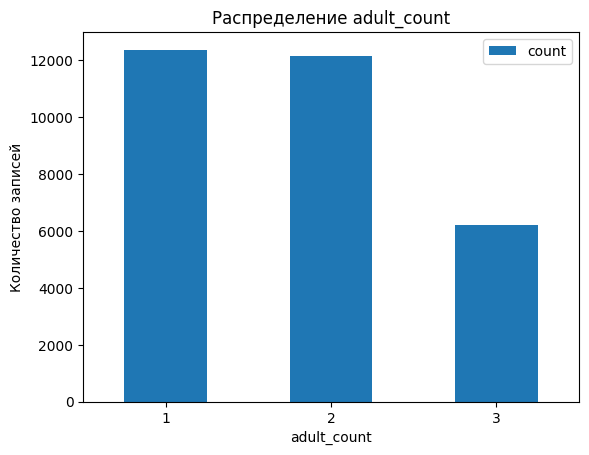

In [15]:
df_bookings['adult_count'] = df_bookings['adult_count'].apply(lambda x: x if x < 100 else int(x/100))
pd.DataFrame(df_bookings['adult_count'].value_counts()).plot(
    kind='bar',
    title='Распределение adult_count',
    xlabel='adult_count',
    ylabel='Количество записей',
    rot=0,
)
plt.show()

<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Верно! Здесь явная ошибка записи. Нужно убрать нули у аномальных значений.</font>

Данные приведены в корректное состояние.

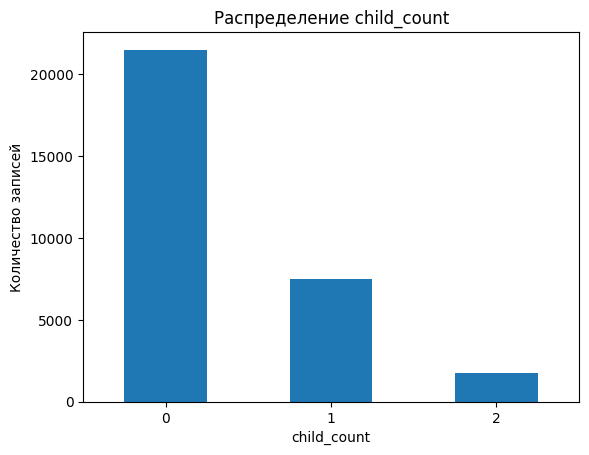

In [16]:
df_bookings['child_count'].value_counts().plot(
    kind='bar',
    title='Распределение child_count',
    xlabel='child_count',
    ylabel='Количество записей',
    rot=0
)
plt.show()

Большинство посетителей приезжают без детей.

Исследуем столбец booking_value:

,count,mean,std,min,25%,50%,75%,max
booking_value,30733.0,61679.168347,42737.28917,0.0,33500.0,60300.0,80400.0,417221.2


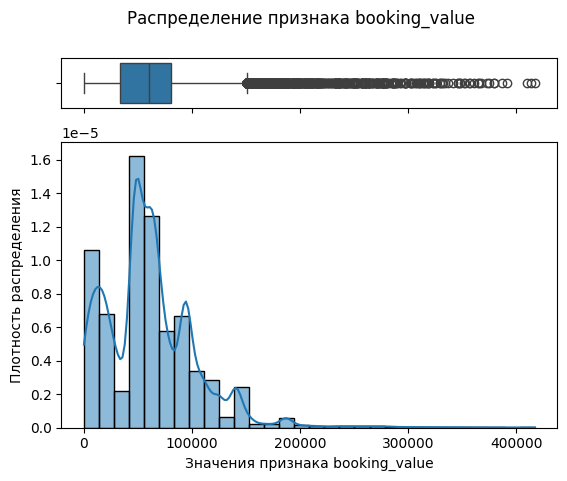

In [17]:
eda_helper.box_hist(df_bookings, 'booking_value', bins=30)

Стоимость бронирования имеет правое смещение и длинный правый хвост, что необязательно говорит о выбросах, которые нужно обрабатывать специальным образом. Скоррее они имеют естесственное происхождение. Медианное значение стоимости - 60к рублей, что достаточно дорого.  Однако так же виден всплеск количества дешевых бронирований в 10-20 тысяч рублей, что может говорить о наличии корпоративных клиентов, которые обычно платять меньшую сумму за номер.

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'>~~Есть много нулевых значений стоимости.
 Причём и у тех кто отменил бронь, и у тех, кто не отменял.
 В данных не должно так быть. Стоимость номера всегда есть. Поэтому, считаем,
 что данные строки по бронированию не качественные. И лучше от них сразу избавиться.~~</font>

</span><br><span style="color: purple; font-weight: bold"> ✅ Комментарий студента № 1: удалим объекты с нулевой стоимостью номера за ночь, так как они выглядят как ошибка ввода даных</span>

<span style="color: blue; font-weight: bold">Комментарий ревьюера 2: </span> ✔️\
<font color='green'> Убрали непонятные данные с нулевой стоимостью.</font>

In [18]:
df_bookings['booking_value'].value_counts().reset_index().query('count > 500')

,booking_value,count
0,46900.0,4512
1,93800.0,2247
2,67000.0,2230
3,53600.0,2190
4,60300.0,2167
5,13400.0,1493
6,6700.0,1460
7,20100.0,1429
8,0.0,1229
9,62300.0,966


В данных примерно 1200 строк без стоимости бронирования. Удалим их из датасета:

In [19]:
df_bookings = df_bookings[df_bookings['booking_value'] > 0]

Исследуем days_until_checkin:

,count,mean,std,min,25%,50%,75%,max
days_until_checkin,29504.0,100.541994,71.926833,2.0,45.0,90.0,144.0,300.0


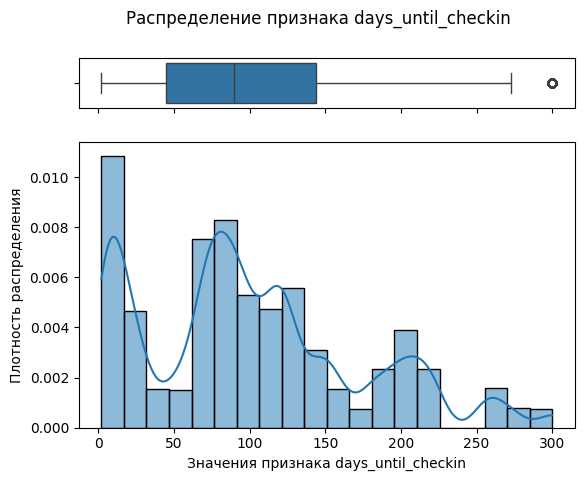

In [20]:
eda_helper.box_hist(df_bookings, 'days_until_checkin', bins=20)

Выделяются группы пользователей:
- бронируют за 0-20 дней
- бронируют за 70-140 дней
- бронируют за 190-210 дней
- бронируют за 260-300 дней

Кажется, что будет хорошим ходом выделить такие категории пользователей в отдельный категориальный признак и учитывать его в обучении. Возьмем это на вооружение, если потребуется дополнительные усиления в виде фича инжениринга.

##### Распределение временных признаков

In [21]:
eda_helper.convert_to_datetime(df_bookings, 'booking_date').head()

Данные в "booking_date" представлены за период 3216 дн. (8.8 л.): 2017-01-01 00:00:00 - 2025-10-22 00:00:00


,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests
0,INN00000,2020-07-08,корпоративное_бронирование,3,0,False,0,0,нет_отказа,6700.0,21,1,0,тип_питания_2,False,тип_1,0
1,INN00001,2021-09-19,корпоративное_бронирование,3,0,True,0,1,нет_отказа,62300.0,15,5,2,тип_питания_2,False,тип_1,1
2,INN00002,2022-11-19,корпоративное_бронирование,3,0,True,0,2,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,0
3,INN00003,2017-02-11,онлайн_бронирование,2,0,False,0,0,нет_отказа,53600.0,150,6,2,тип_питания_1,False,тип_1,0
4,INN00004,2019-03-06,корпоративное_бронирование,1,0,True,1,1,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,1


В датасете представлены бронирования за почти 9 лет: с 2017 по 2025 гг.

##### Распределение категориальных признаков

In [22]:
eda_helper.get_unique_values(df_bookings, cat_columns=['sales_channel', 'meal_plan', 'room_type'], top_n=10)

Уникальные значения всех категориальных признаков:



,feature,num_of_unique_vals,unique_vals
0,sales_channel,3,"корпоративное_бронирование, онлайн_бронирование, офлайн_бронирование"
1,meal_plan,5,"не выбран, не выбрант, тип_питания_1, тип_питания_2, тип_питания_3"
2,room_type,7,"тип_1, тип_2, тип_3, тип_4, тип_5, тип_6, тип_7"


Высококардинальных признаков в датасете нет, но имеются неявные дубликаты из-за опечатки в значениях столбца meal_plan:

In [23]:
df_bookings['meal_plan'] = df_bookings['meal_plan'].apply(lambda x: 'не выбран' if x == 'не выбрант' else x)

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<font color='green'>Отлично, поправили опечатку!</font>

<span style="color: blue;: bold">Комментарий ревьюера : </span> ⚠️\
<span style="color: darkorange"> В Пандас есть отличный метод `replace`</span>

In [24]:
eda_helper.get_unique_values(df_bookings, cat_columns=['sales_channel', 'meal_plan', 'room_type'], top_n=10)

Уникальные значения всех категориальных признаков:



,feature,num_of_unique_vals,unique_vals
0,sales_channel,3,"корпоративное_бронирование, онлайн_бронирование, офлайн_бронирование"
1,meal_plan,4,"не выбран, тип_питания_1, тип_питания_2, тип_питания_3"
2,room_type,7,"тип_1, тип_2, тип_3, тип_4, тип_5, тип_6, тип_7"


Опечатка исправлена.

Преобразования категориальных признаков не потребуется, так как планируется использовать модели со встроенной поддержкой категорий. Достаточно преобразовтать тип кат признаков к типу category:

In [25]:
CAT_FEATURES = ['sales_channel', 'meal_plan', 'room_type']
for cat_feature in CAT_FEATURES:
    df_bookings[cat_feature] = df_bookings[cat_feature].astype('category')
df_bookings.info()

<class 'pandas.DataFrame'>
Index: 29504 entries, 0 to 30735
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   booking_id                 29504 non-null  str           
 1   booking_date               29504 non-null  datetime64[us]
 2   sales_channel              29504 non-null  category      
 3   adult_count                29504 non-null  int64         
 4   child_count                29504 non-null  int64         
 5   returning_customer         29504 non-null  bool          
 6   previous_cancellations     29504 non-null  int64         
 7   previous_no_shows          29504 non-null  int64         
 8   booking_status             29504 non-null  str           
 9   booking_value              29504 non-null  float64       
 10  days_until_checkin         29504 non-null  int64         
 11  weekday_nights             29504 non-null  int64         
 12  weekend_nights      

##### Распределение целевой переменной

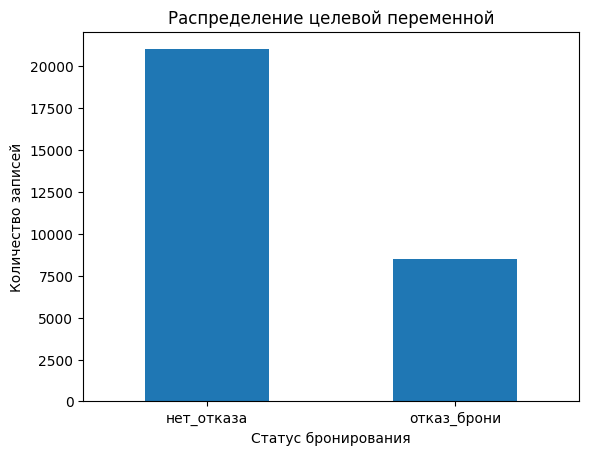

In [26]:
df_bookings['booking_status'].value_counts().plot(
    kind='bar',
    rot=0,
    title='Распределение целевой переменной',
    xlabel='Статус бронирования',
    ylabel='Количество записей')
plt.show()


In [27]:
df_bookings['booking_status'].value_counts(normalize=True)

booking_status
нет_отказа     0.712175
отказ_брони    0.287825
Name: proportion, dtype: float64

Мы имеем дело с незначительным дисбалансом классов положительный класс соотносится с отрицательным как 3 к 7. Можно учесть данный факт при обучении модели, передавая ей параметр class_weight='balanced'.

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<font color='green'> Нашли дисбаланс.</font>

Корреляционный анализ целевой перменной и признаков произведем после объединения таблиц.

Преобразуем целевую переменную к числовому типу:

In [28]:
df_bookings['booking_status'] = df_bookings['booking_status'].apply(lambda x: 1 if x == 'отказ_брони' else 0)

#### Таблица hotel_reviews

Описание столбцов в таблице с отзывами:

- `customer_id` — уникальный идентификатор клиента. Позволяет связать отзыв с конкретным гостем. Пример: C0003.
- `booking_id` — идентификатор бронирования, по которому оставлен отзыв. Пример: INN000201614.
- `review_date` — дата оставления отзыва. Например: 2018-11-21.
- `stay_rating` — оценка проживания от 1 (самая низкая) до 5 (самая высокая).
- `review_text` — текстовый комментарий клиента о проживании: плюсы, минусы, впечатления. Пример: «Неплохо. Приветливый персонал на ресепшн, но завтрак однообразный. Питание в ресторане понравилось».


##### Дубликаты

Теперь исследуем дубликаты в таблице отзывов:

In [29]:
eda_helper.drop_duplicates(df_reviews)

Найдено 0 дубликатов по всем столбцам
Дубликатов не обнаружено


Явных дубликатов в таблице с отзывами нет. Исследуем дубликаты по customer_id, booking_id, review_date.


In [30]:
df_reviews[df_reviews.duplicated(subset=['customer_id', 'booking_id', 'review_date'], keep=False)] \
    .sort_values(by=['customer_id', 'booking_id', 'review_date'])

,customer_id,booking_id,review_date,stay_rating,review_text
154,C0112,INN00200,2018-01-26,3,"Неплохо. красивый интерьер, но дорого для такого качества. Для детей ничего нет, им было скучно. Кондиционер не справлялся, тяжело в номере"
22646,C0112,INN00200,2018-01-26,3,"Неплохо. дружелюбная атмосфера, но насекомые в номере. Для детей ничего нет, им было скучно. Кондиционер не справлялся, тяжело в номере"
225,C0169,INN00311,2019-10-19,3,"Неплохо. качественные продукты на завтрак, но не работает телевизор. Для детей ничего нет, им было скучно."
23638,C0169,INN00311,2019-10-19,3,"Неплохо. комфортабельные зоны отдыха, но отсутствие парковки. Для детей ничего нет, им было скучно."
273,C0200,INN00373,2018-04-19,4,"Отличный отель! приятный аромат в холле. это больше, чем отель — это дом вдали от дома"
...,...,...,...,...,...
25050,C9402,INN17542,2018-01-28,4,Отличный отель! красивое оформление территории. Зимой отель хорошо отапливается.
12585,C9448,INN17645,2021-12-16,4,Отличный отель! быстро заселили. отель в моём личном топе — 5/5 Дети в восторге от игровой зоны!
23849,C9448,INN17645,2021-12-16,4,Отличный отель! приветливый персонал на ресепшн. Дети в восторге от игровой зоны!
12995,C9781,INN18246,2020-08-17,4,Отличный отель! отличный отель. вернусь с семьёй в следующий раз Дети в восторге от игровой зоны!


Такие дубликаты есть в числе 260 строк. Возможная причина их возникновения - пользователь отредактировал свой отзыв. Узнать какой из отзывов правильный - не представляется возможным, поэтому придется отбросить такие дубликаты.

In [31]:
eda_helper.drop_duplicates(df_reviews, ['customer_id', 'booking_id', 'review_date'])

Найдено 130 дубликатов по ['customer_id', 'booking_id', 'review_date'] столбцам


Удалено 130 строк (0.5%) из 25177


Искать дубликаты по только по customer_id, booking_id не имеет смысла, так как клиент мог оставить отзыв на свое посещение - необходимо брать тот отзыв, который позже всего размещен после даты посещения - это и будет последний исправленный отзыв клиента.

Удалено 130 дублирующих строк (0.5% от датасета)

Исследуем дубликаты в тесте ревью:

In [32]:
df_rev_dups = df_reviews[df_reviews.duplicated(subset=['review_text'], keep=False)] \
    .sort_values(by=['review_text'])
df_rev_dups.head(8)

,customer_id,booking_id,review_date,stay_rating,review_text
22942,C3224,INN06016,2019-08-18,5,Идеальный отель! Всё на высшем уровне. отель в моём личном топе — 5/5 Дети в восторге от игровой зоны!
18426,C13894,INN25868,2020-10-10,5,Идеальный отель! Всё на высшем уровне. отель в моём личном топе — 5/5 Дети в восторге от игровой зоны!
18149,C13695,INN25487,2017-09-21,5,"Идеальный отель! Всё на высшем уровне. отель, который стал частью моих путешествий Дети в восторге от игровой зоны!"
4270,C3166,INN05906,2020-11-03,5,"Идеальный отель! Всё на высшем уровне. отель, который стал частью моих путешествий Дети в восторге от игровой зоны!"
15836,C11917,INN22223,2020-12-20,2,Крайне недоволен. не работает телевизор. не работает сейф в номере — рисковал с ценными вещами
22329,C11840,INN22080,2018-01-22,2,Крайне недоволен. не работает телевизор. не работает сейф в номере — рисковал с ценными вещами
5046,C3742,INN07000,2023-08-18,2,"Крайне недоволен. неисправная сантехника. мини-бар пустой, хотя включён в стоимость В номерах холодно. второго одеяла пришлось выпрашивать"
2641,C1957,INN03654,2019-09-23,2,"Крайне недоволен. неисправная сантехника. мини-бар пустой, хотя включён в стоимость В номерах холодно. второго одеяла пришлось выпрашивать"


In [33]:
dups_count = len(df_reviews[df_reviews.duplicated(subset=['review_text'], keep=False)]) - \
             len(df_reviews[df_reviews.duplicated(subset=['review_text'], keep='first')])

print(f'Количество дублей в отзывах: {dups_count} ({dups_count / len(df_reviews) * 100:.0f})%')

Количество дублей в отзывах: 4586 (18)%


In [34]:
dups_count = len(df_reviews[df_reviews.duplicated(subset=['customer_id', 'review_text'], keep=False)]) - \
             len(df_reviews[df_reviews.duplicated(subset=['customer_id', 'review_text'], keep='first')])

print(f'Количество дублей по тексту и customer_id: {dups_count} ({dups_count / len(df_reviews) * 100:.2f})%')

Количество дублей по тексту и customer_id: 15 (0.06)%


Достаточно много текстов отзывов повторяется влоть до символа - 4.5к строк дублей, что составляет 18% датасета.
Причем отзывы написаны разными людьми (одинаковые отзывы по customer_id и review_text составяют всего 0.06%). Можно предположить, что отзывы сгенерированы под задачу практикума.

В связи с этим не будем удалять дублирующие тексты.

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

Исследуем признак с датой и числовой признак в датасете:

In [35]:
eda_helper.convert_to_datetime(df_reviews, 'review_date').head(5)

Данные в "review_date" представлены за период 3332 дн. (9.1 л.): 2017-01-17 00:00:00 - 2026-03-03 00:00:00


,customer_id,booking_id,review_date,stay_rating,review_text
0,C0001,INN00000,2020-08-21,3,"Неплохо. тихо и спокойно, но отсутствие фена в номере. Кондиционер не справлялся, тяжело в номере"
1,C0001,INN00001,2021-10-15,3,"Неплохо. красивое оформление территории, но неработающий лифт."
2,C0001,INN00002,2023-03-08,4,Отличный отель! удобные парковочные места. здесь всегда ждут как родных
3,C0002,INN00003,2017-08-13,3,"Неплохо. тёплый приём, но неисправная сантехника. В номерах холодно. второго одеяла пришлось выпрашивать"
4,C0003,INN00004,2019-07-12,4,Отличный отель! качественная косметика в ванной. сервис здесь — это забота на максимум


Данные в таблице с отзывами представлены за 9 лет с 2017 до 2026 год.

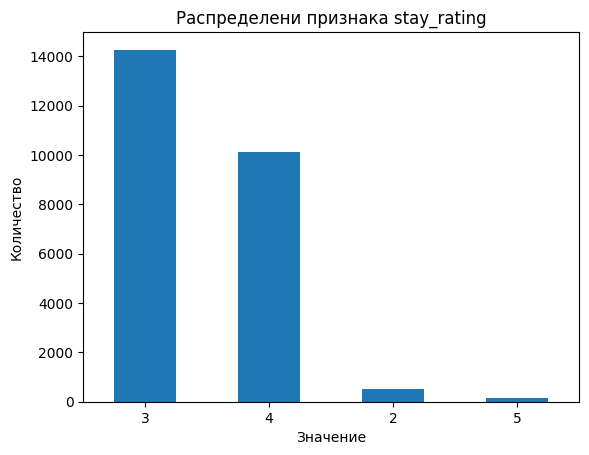

In [36]:
df_reviews['stay_rating'].value_counts().plot(
    kind='bar',
    title='Распределени признака stay_rating',
    xlabel='Значение',
    rot=0,
    ylabel='Количество'
)
plt.show()

In [37]:
round(df_reviews['stay_rating'].value_counts(normalize=True)*100, 0).astype(int)

stay_rating
3    57
4    40
2     2
5     1
Name: proportion, dtype: int64

Посмотрим на точные доли каждой оценки:

Видно, что большинство клиентов оставляют средние оценки за проживание в отеле:
- 3 ->   57 %
- 4 ->   40 %
- 2 ->    2 %
- 5 ->    1 %

Интересно, самая частая оценка - это 3 балла. Категоричных "отлично" и "неуд" 1-2%. Можно сделать вывод, что есть какие-то системные недостатки в отеле, на которые пользователи обращают внимание и снижают баллы.

#### Выводы по EDA

В ходе EDA были исследованы две таблицы: hotel_bookings (35 341 строк, 17 столбцов) и hotel_reviews (25 177 строк, 5 столбцов). Пропущенных значений в обеих таблицах не обнаружено.

Таблица hotel_bookings:

- Дубликаты: удалено 4 608 строк (13%) по всем 17 столбцам - это существенная доля, которая могла бы негативно сказаться на обучении модели. После очистки датасет составляет 30 733 записи, что по-прежнему достаточно для обучения.

- Ошибка ввода в `adult_count`: в нескольких тысячах объектов количество взрослых гостей было завышено ровно в 100 раз - значения 100, 200, 300 вместо ожидаемых 1, 2, 3. Данные исправлены делением на 100.

- `booking_value`: распределение стоимости бронирования имеет правое смещение с длинным правым хвостом (медиана 60к руб., максимум ~417 221 руб.). Выбросы, скорее всего, имеют естественное происхождение и не удалялись. Также заметен всплеск дешёвых бронирований в диапазоне 10–20 тыс. руб. - вероятно, корпоративные клиенты с льготными тарифами.

- `days_until_checkin`: в распределении прослеживаются 4 группы клиентов по горизонту планирования: 0–20 дней (спонтанные), 70–140 дней (заблаговременные), 190–210 дней и 260–300 дней (планирующие сильно заранее). Это потенциально полезный признак для фича-инжиниринга - можно выделить категорию горизонта бронирования.

- Опечатка в `meal_plan`: значение `'не выбрант'` исправлено на `'не выбран'`, количество уникальных значений сократилось с 5 до 4.

- Временной охват: бронирования охватывают период ~9 лет - с января 2017 по октябрь 2025 года.

- Целевая переменная (`booking_status`): наблюдается умеренный дисбаланс классов - 71.2% бронирований без отмены (`нет_отказа`) против 28.8% отменённых (`отказ_брони`). Соотношение не критично, но стоит учесть при обучении.

- Преобразования типов: столбец `booking_date` приведён к типу `datetime`, категориальные признаки `sales_channel`, `meal_plan`, `room_type` - к типу `category`. Целевая переменная закодирована в бинарный формат: 1 - отмена, 0 - нет.

Таблица hotel_reviews:

- Явных дубликатов нет, однако обнаружены 130 строк (0.5%) с одинаковыми `customer_id`, `booking_id` и `review_date` при разном тексте - вероятно, клиент редактировал отзыв. Поскольку определить "правильный" вариант невозможно, дубликаты удалены.

- Дубликаты по тексту отзыва: 18% строк содержат повторяющиеся тексты, написанные разными клиентами. Это признак синтетической генерации данных под задачу практикума. Удалять такие строки не стали - они принадлежат разным клиентам/бронированиям и несут некоторый сигнал для цели исследований.

- `stay_rating`: подавляющее большинство оценок - 3 балла (57%) и 4 балла (40%). Оценки 5 и 2 встречаются крайне редко (1% и 2% соответственно). Это говорит о том, что у отеля есть системные недостатки, которые мешают клиентам ставить высшие оценки, но в целом сервис приемлемый.

- Временной охват: отзывы охватывают период ~9 лет - с января 2017 по март 2026 года.

Итог: данные в целом качественные, пропусков нет. Основные проблемы - дубликаты в таблице бронирований (13%) и ошибка ввода в `adult_count` - успешно устранены. Дисбаланс классов умеренный и поддаётся коррекции на этапе обучения. Таблицы готовы к объединению и дальнейшему фича-инжинирингу.

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

### Объединение таблиц

Объединяем таблицы бронирований и отзывов. Для каждого бронирования надо найти последний отзыв клиента, оставленный ДО даты этого бронирования, чтобы избежать утечки данных (подглядывание в будущее).

В df_bookings нет customer_id, поэтому сначала добавляем его через join по booking_id с таблицей отзывов. После этого у каждого бронирования появляется идентификатор клиента, который нужен для дальнейшей группировки.

Далее используем merge_asof - join по ближайшему значению даты. Для каждой строки из df_bookings он ищет строку из df_reviews с максимальным review_date, который не превышает booking_date, у того же customer_id. Параметр direction='backward' задает направление поиска - только назад по времени.

Теоретически может возникнуть ситуация, когда в один день пользователь напишет 2 отзыва, тогда отступ с помощью backward не перешагнет на предыдущую дату и модель будет таким образом "заглядывать" в будущее. Чтобы этого избежать сначала исследуем сколько таких проблем возникает. Если их немного, то просто удалим дублирующиеся по дате и пользователю отзывы.

Бронирования, у которых нет ни одного предшествующего отзыва клиента, получат NaN в полях отзыва - это ожидаемо, так как клиент мог бронировать впервые.

Исследуем, есть ли пользователи, которые написали 2 отзыва в один день:

In [38]:
df_reviews.groupby(['customer_id', 'review_date']).agg(
    count=('review_date', 'count')
).query('count > 1')


,,count
customer_id,review_date,
C7170,2020-11-13,2


Такой пользователь всего один. И у него всего 2 отзыва, написанные в один день. Посмотрим на них:

In [39]:
df_reviews[(df_reviews['customer_id'] == "C7170") & (df_reviews['review_date'] == "2020-11-13")]

,customer_id,booking_id,review_date,stay_rating,review_text
9597,C7170,INN13450,2020-11-13,3,"Неплохо. вежливый персонал, но медленное обслуживание. Для детей ничего нет, им было скучно. Парковка далеко и плохо освещена. В номерах холодно. второго одеяла пришлось выпрашивать"
9598,C7170,INN13451,2020-11-13,3,"Неплохо. приятный аромат в холле, но неубранный мусор в коридоре. Для детей ничего нет, им было скучно."


Дедуплицируем записи по customer_id и review_date далее.

In [40]:
# добавляем customer_id в df_bookings через join по booking_id
df_bookings_with_customer = df_bookings.merge(
    df_reviews[['booking_id', 'customer_id']],
    on='booking_id',
    how='left'
)

# конвертируем даты - merge_asof требует числовой или datetime тип
df_bookings_with_customer['booking_date'] = pd.to_datetime(df_bookings_with_customer['booking_date'])
df_reviews['review_date'] = pd.to_datetime(df_reviews['review_date'])

# сортируем по ключу слияния
df_bookings_sorted = df_bookings_with_customer.sort_values('booking_date')

# ✅ Комментарий студента № 1: исправлена сортировка для детерминированного удаления дубликатов
df_reviews_sorted = df_reviews.sort_values(
    ['customer_id', 'review_date', 'booking_id'],
    ascending=[True, True, False]  # booking_id по убыванию, чтобы keep='last' взял максимальный
)

# оставляем один отзыв на клиента на дату - берем последний по booking_id (произвольный выбор)
# это делаем на случай, когда пользователь оставил несколько отзывов в одну дату
df_reviews_dedup = df_reviews_sorted \
    .drop_duplicates(subset=['customer_id', 'review_date'], keep='last')

df_reviews_dedup = df_reviews_dedup.sort_values(['customer_id', 'review_date'])

 # ✅ Комментарий студента № 1: исправлено - отделяем строки с пропусками в customer_id, потом их приклеиваем
df_bookings_nonnull = df_bookings_sorted[df_bookings_sorted['customer_id'].notna()].copy()
df_bookings_null = df_bookings_sorted[df_bookings_sorted['customer_id'].isna()].copy()

# для каждого бронирования берем последний отзыв клиента ДО booking_date
df_merged = pd.merge_asof(
    df_bookings_nonnull,
    df_reviews_dedup[['customer_id', 'review_date', 'stay_rating', 'review_text']].sort_values('review_date'),
    left_on='booking_date',
    right_on='review_date',
    by='customer_id',
    direction='backward',
    allow_exact_matches=False,  # ✅ Комментарий студента № 1: исправлено строгое совпадение дат, чтобы брался отзыв ДО booking_date
)

# Возвращаем бронирования без customer_id
df = pd.concat([df_merged, df_bookings_null], ignore_index=True)

# исследуем базовую информацию о получившемся датасете
eda_helper.df_info(df, 'joined')

--------------------------------------------------
Описание датасета joined:
Датасет joined содержит 32533 строк и 21 столбцов.
Размер датасета joined в памяти: 4.33 MB
--------------------------------------------------
Данные датасета joined:
--------------------------------------------------


,place,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests,customer_id,review_date,stay_rating,review_text
0,head,INN21754,2017-01-01,онлайн_бронирование,3,2,False,0,0,0,67000.0,124,8,2,тип_питания_2,False,тип_2,0,C11662,NaT,NaN,NaN
1,head,INN21754,2017-01-01,онлайн_бронирование,3,2,False,0,0,0,67000.0,124,8,2,тип_питания_2,False,тип_2,0,C11662,NaT,NaN,NaN
2,head,INN21754,2017-01-01,онлайн_бронирование,3,2,False,0,0,0,67000.0,124,8,2,тип_питания_2,False,тип_2,0,C11662,NaT,NaN,NaN
6014,random,INN20171,2018-06-14,онлайн_бронирование,1,1,False,0,0,0,53600.0,21,6,2,не выбран,False,тип_6,1,C10812,NaT,NaN,NaN
10376,random,INN06399,2019-04-01,офлайн_бронирование,1,1,True,1,1,0,46900.0,75,5,2,тип_питания_1,True,тип_1,1,C3421,NaT,NaN,NaN
29311,random,INN29027,2019-12-07,корпоративное_бронирование,3,0,False,0,0,1,62300.0,259,5,2,тип_питания_1,False,тип_1,0,NaN,NaT,NaN,NaN
32530,tail,INN05316,2025-07-01,онлайн_бронирование,2,0,True,0,4,1,13400.0,100,2,0,тип_питания_1,False,тип_1,0,NaN,NaT,NaN,NaN
32531,tail,INN12950,2025-07-01,корпоративное_бронирование,1,0,True,0,4,1,140700.0,7,15,6,тип_питания_2,False,тип_1,0,NaN,NaT,NaN,NaN
32532,tail,INN18736,2025-10-22,офлайн_бронирование,2,0,True,0,4,1,107200.0,90,12,4,тип_питания_1,True,тип_1,1,NaN,NaT,NaN,NaN


--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 32533 entries, 0 to 32532
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   booking_id                 32533 non-null  str           
 1   booking_date               32533 non-null  datetime64[us]
 2   sales_channel              32533 non-null  category      
 3   adult_count                32533 non-null  int64         
 4   child_count                32533 non-null  int64         
 5   returning_customer         32533 non-null  bool          
 6   previous_cancellations     32533 non-null  int64         
 7   previous_no_shows          32533 non-null  int64         
 8   booking_status             32533 non-null  int64         
 9   booking_value              32533 non-null  float64       
 10  days_until_checkin         32533 non-null  int64         
 11  weekday_nights             

,index,Количество строк,Количество пропусков,Процент пропусков
0,review_text,32533,23356,71.8
1,stay_rating,32533,23356,71.8
2,review_date,32533,23356,71.8
3,customer_id,32533,8492,26.1


<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<font color='green'> Верно, что применяется `merge_asof`</font>

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'>~~`merge_asof` с `direction='backward'` (по умолчанию) включает точное совпадение дат (allow_exact_matches=True). Отзыв должен быть строго До бронирования.~~</span>

</span><br><span style="color: purple; font-weight: bold"> ✅ Комментарий студента № 1: исправлено, добавил параметр allow_exact_matches=False</span>

In [41]:
# проверим инвариант с датами
mask_err = df['review_date'] >= df['booking_date']
assert len(df[mask_err]) == 0

<font color='blue'><b>Комментарий ревьюера : </b></font> ⚠️\
<font color='darkorange'>Брони без customer_id попадают в merge_asof с NaN и могут получить чужие отзывы. Нужна фильтрация до мержа и возврат после.</font>

</span><br><span style="color: purple; font-weight: bold"> ✅ Комментарий студента № 1: исправлено</span>

<font color='blue'><b>Комментарий ревьюера : </b></font> ⚠️\
<font color='darkorange'>`drop_duplicates` применяется к уже отсортированному `df_reviews_sorted` по `review_date`. При одинаковых customer_id и review_date `keep='last'` берёт последнюю строку в порядке сортировки — но сортировка только по review_date, так что при равных датах порядок внутри группы не определён. Если важно взять конкретный отзыв (например с максимальным booking_id), нужна дополнительная сортировка перед drop_duplicates.</font>

</span><br><span style="color: purple; font-weight: bold"> ✅ Комментарий студента № 1: исправлено</span>

<span style="color: blue; font-weight:">Комментарий ревьюера 2: </span> ✔️\
<span style="color: green"> Отличная доработка — все замечания закрыты.Отличная доработка — все замечания закрыты.</span>

В результирующем датасете достаточно много пропусков в присоединенных из df_reviews столбцах. Это нормально - предыдущие отзывы есть только у 28% пользователей. Кроме того видно, что customer_id не приджойнился для 26% строк в таблице df_bookings по booking_id - это бронирования пользователей, которые вообще не имеют отзывов.

Пропуски будут заменены на специальные значения на этапе обучения.

#### Корреляционный анализ признаков

Теперь, когда мы имеем объединенные данные, произведем корреляционный анализ признаков.

interval columns not set, guessing: ['adult_count', 'child_count', 'previous_cancellations', 'previous_no_shows', 'booking_status', 'booking_value', 'days_until_checkin', 'weekday_nights', 'weekend_nights', 'customer_special_requests', 'stay_rating']


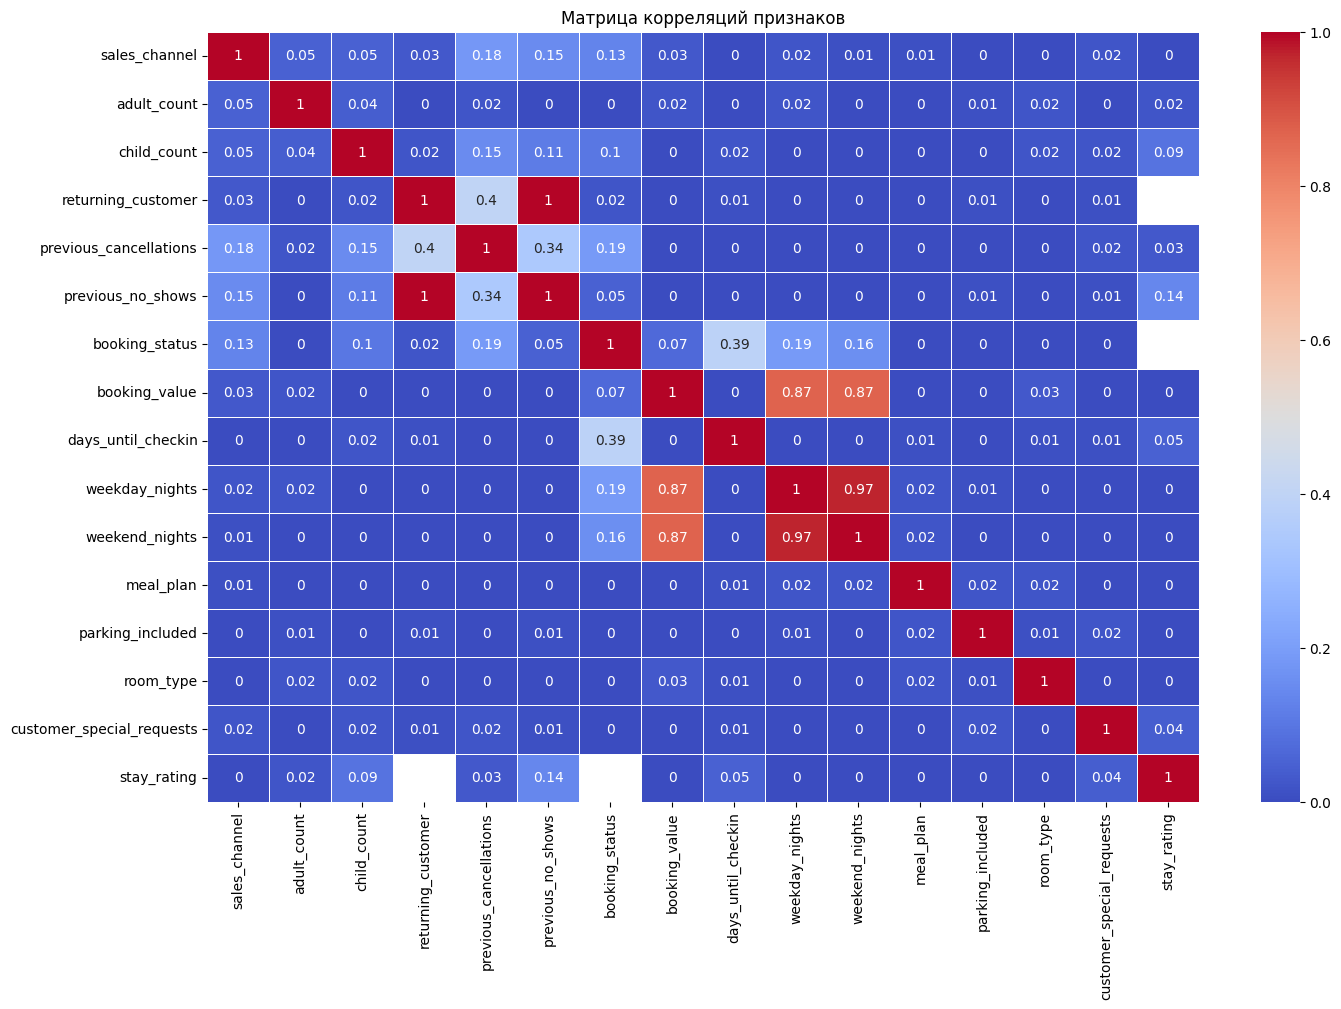

In [42]:
df_for_corr = df.drop(columns=['customer_id', 'review_date', 'review_text', 'booking_date', 'booking_id'])

full_corr_matrix = df_for_corr.phik_matrix()
corr_displayer = CorrelationDisplayer(full_corr_matrix)
corr_displayer.draw_corr_matrix_full()

<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'>Здорово,что применена `phik` для анализа и нелинейных зависимостей</font>

Ддя наглядности рассмотрим топ парных корреляций:

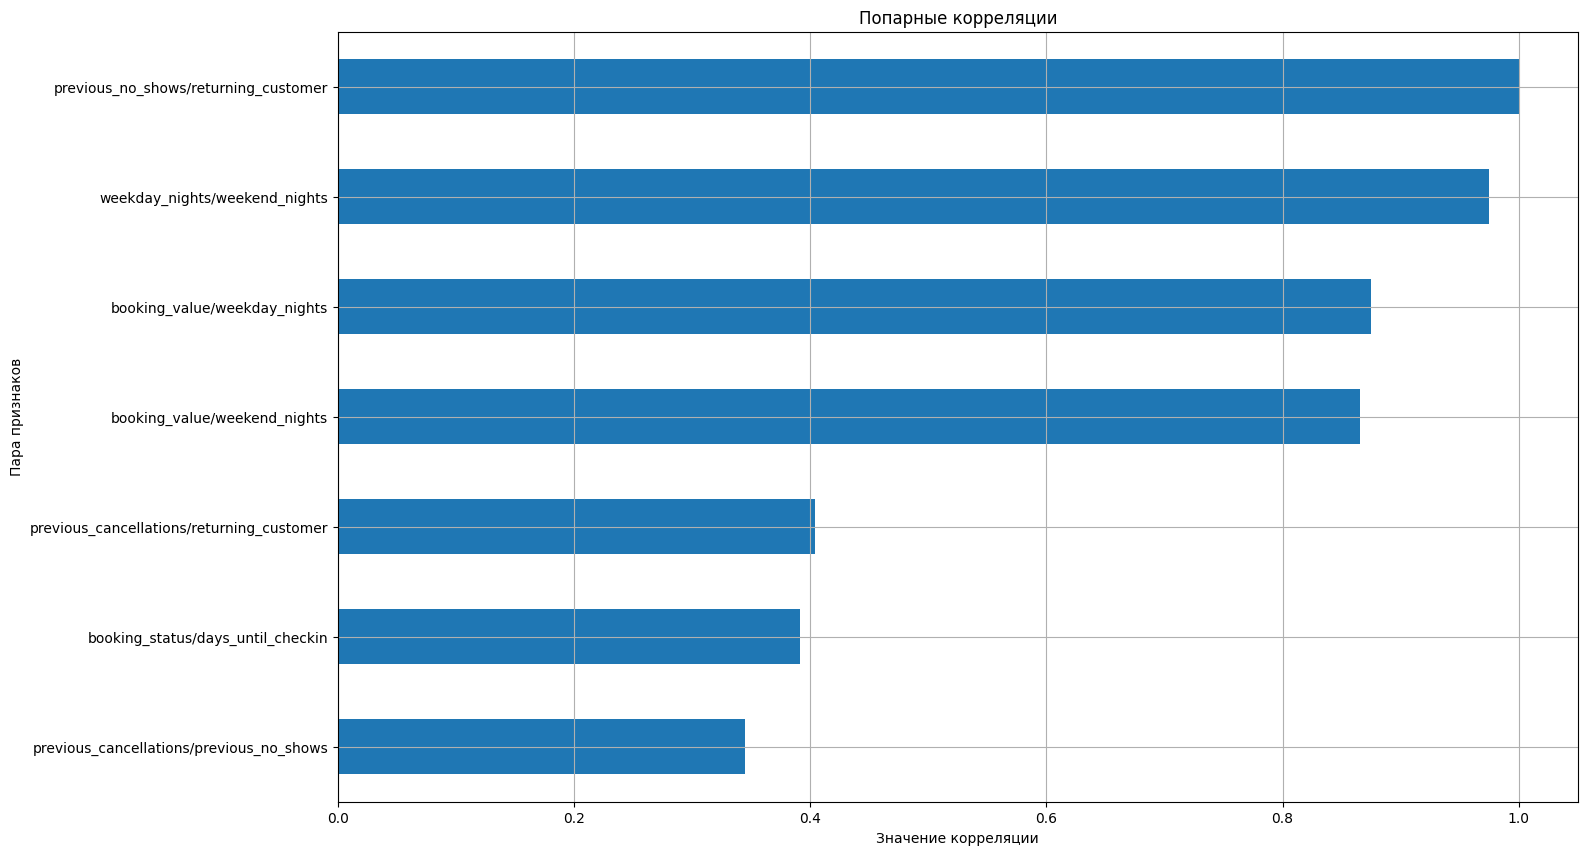

,correlation,order_pair
0,1.000000,previous_no_shows/returning_customer
1,0.974921,weekday_nights/weekend_nights
2,0.874928,booking_value/weekday_nights
3,0.865734,booking_value/weekend_nights
4,0.403743,previous_cancellations/returning_customer
5,0.391394,booking_status/days_until_checkin
6,0.344963,previous_cancellations/previous_no_shows


In [43]:
corr_displayer.draw_pair_correlations(corr_threshold=0.3)

В таблице и на графике видны самые коррелированные пары признаков.

Построим топ признаков по корреляции с целевой переменной:

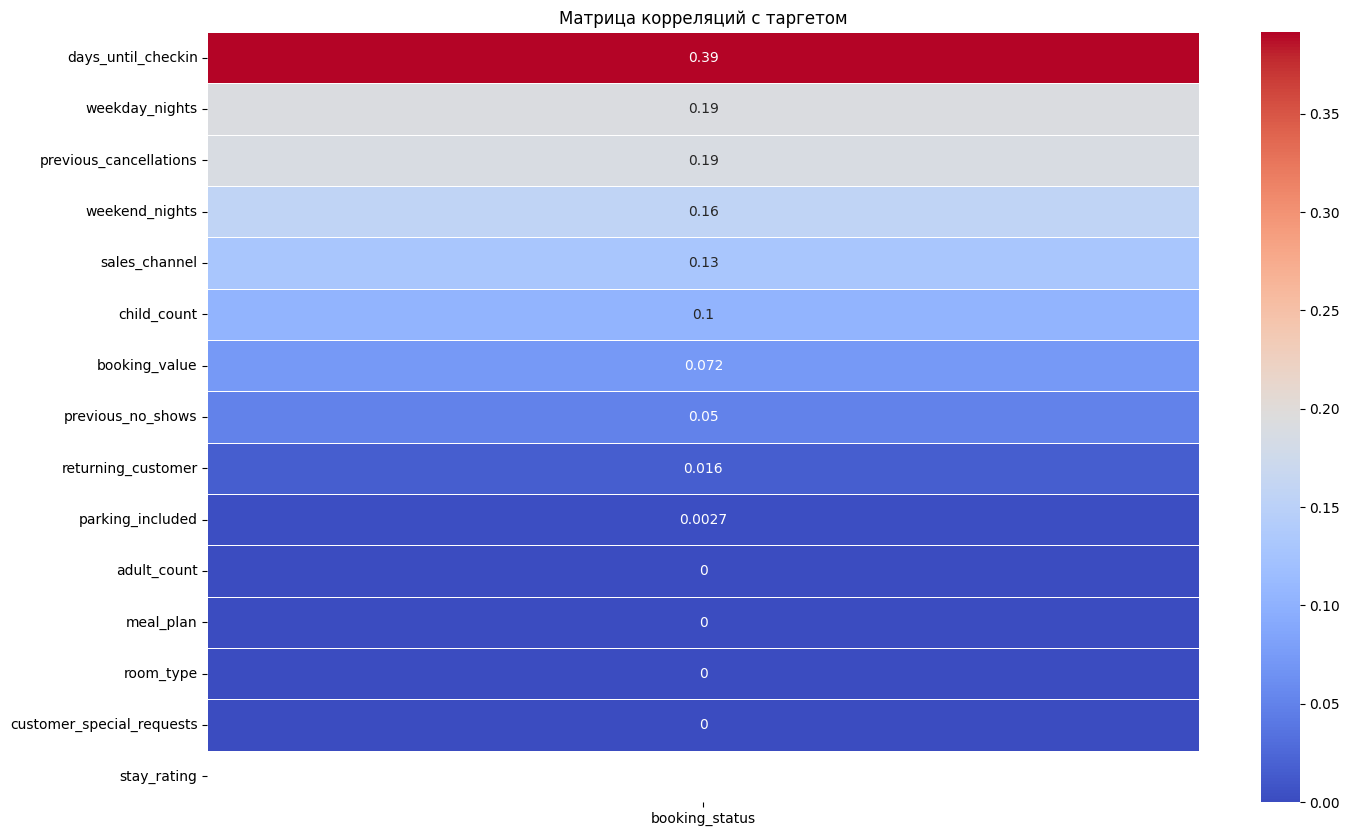

In [44]:
corr_displayer.draw_corr_matrix_with_target(TARGET_COL_NAME)

По корреляционной матрице и соответствующей ей тепловой карте видно:
- есть абсолютно или очень сильно скоррелированные признаки, например, `nights_num/weekend_nights` или `previous_no_shows/returning_customer`, из-за которых некоторые модели, например, RandomForest, могут быть нестабильны. Мы планируем использовать менее подверженные этой проблеме ансамблевые модели типа XGBoost и Catboost, поэтому оставим скоррелированные признаки в датасете. 
- Присутствует умеренная корреляция между целевой переменной и признаком `days_until_checkin`.
- Так же имеется слабая корреляция с `weekday/weekend_nights`, `previous_cancellation`, `sales_channel`, `booking_values`, `child_count`.

Вероятно, что при оценке значимости признаков даннные признаки будут в топе. 

### Создание новых признаков

- Создайте не менее трёх признаков на основе данных о брони.

- Создайте новые признаки на основе текстов отзывов, используя один из методов векторизации. Решение о количестве таких признаков примите самостоятельно.

- Сделать выводы о созданных признаках.

#### Создание простых признаков

В таблце с бронями для анализа не хватает нескольких столбцов, которые могут быть полезны и при обучении:
1. Количество ночей бронирования = количество выходных + будней
2. Стоимость номера за ночь, вычисляемая как (стоимость бронирования) /(количество ночей бронирования)
3. Категория "заблаговременности бронирования" пользователя `days_until_checkin_cat`:
    - `koekaker`: бронируют за 0-20 дней
    - `normis`: бронируют за 70-140 дней
    - `pensioner`: бронируют за 190-210 дней
    - `koshey`: бронируют за 260-300 дней

Кроме того добавим несколько признаков, улавливающих сезонность:
1. Вспомогательный признак checkin_date = booking_date + days_until_checkin
2. Месяц заезда checkin_month - показывает общую сезонность в течение года
3. День месяца заезда checkin_day_of_month - показывает сезонность в течение месяца, связано с выплатой зарплат и премий
4. День недели заезда checkin_day_of_week - показывает сезонность в течение недели, связано выходными


In [45]:
def feature_engineering(df):
    df['nights_num'] = df['weekday_nights'] + df['weekend_nights']
    df['price_per_night'] = df['booking_value'] / df['nights_num']
    df['days_until_checkin_cat'] = df['days_until_checkin'].apply(
        lambda x: 'koekaker_20' if x <= 20 else 'normis_140' if x <= 140 else 'pensioner_210' if x <= 210 else 'koshey'
    ).astype('category')

    df['checkin_date'] = df['booking_date'] + df['days_until_checkin'].astype('timedelta64[D]')
    df['checkin_month'] = df['checkin_date'].dt.month
    df['checkin_day_of_month'] = df['checkin_date'].dt.day
    df['checkin_day_of_week'] = df['checkin_date'].dt.dayofweek
    return df

df = feature_engineering(df)
df.sample(5, random_state=RANDOM_STATE)

,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests,customer_id,review_date,stay_rating,review_text,nights_num,price_per_night,days_until_checkin_cat,checkin_date,checkin_month,checkin_day_of_month,checkin_day_of_week
10376,INN06399,2019-04-01,офлайн_бронирование,1,1,True,1,1,0,46900.0,75,5,2,тип_питания_1,True,тип_1,1,C3421,NaT,NaN,NaN,7,6700.0,normis_140,2019-06-15,6,15,5
6014,INN20171,2018-06-14,онлайн_бронирование,1,1,False,0,0,0,53600.0,21,6,2,не выбран,False,тип_6,1,C10812,NaT,NaN,NaN,8,6700.0,normis_140,2018-07-05,7,5,3
29311,INN29027,2019-12-07,корпоративное_бронирование,3,0,False,0,0,1,62300.0,259,5,2,тип_питания_1,False,тип_1,0,NaN,NaT,NaN,NaN,7,8900.0,koshey,2020-08-22,8,22,5
7653,INN04734,2018-10-05,корпоративное_бронирование,2,0,True,2,2,0,46900.0,11,5,2,тип_питания_1,False,тип_1,2,C2533,2018-04-14,3.0,"Неплохо. быстрый интернет, но отсутствие парковки. В номерах холодно. второго одеяла пришлось выпрашивать",7,6700.0,koekaker_20,2018-10-16,10,16,1
18134,INN03464,2020-07-25,корпоративное_бронирование,1,1,False,0,0,0,19985.4,100,1,0,тип_питания_1,False,тип_1,1,C1851,NaT,NaN,NaN,1,19985.4,normis_140,2020-11-02,11,2,0


<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

Исследуем полученные столбцы:

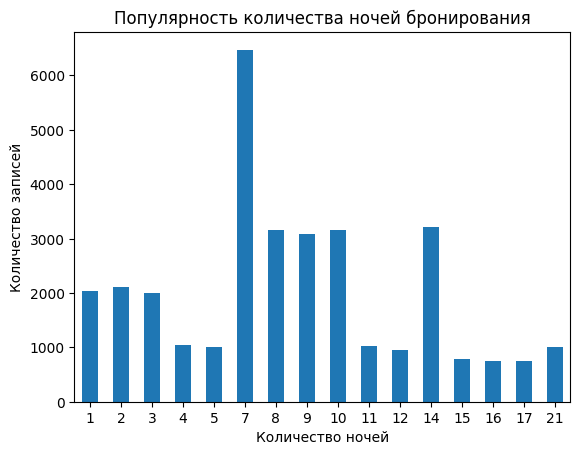

In [46]:
df['nights_num'].value_counts().sort_index().plot(
    kind='bar',
    title='Популярность количества ночей бронирования',
    xlabel='Количество ночей',
    ylabel='Количество записей',
    rot=0
)
plt.show()

На графике видно, что популярнее всего бронирования на неделю. Чуть менее популярные длительности бронирования - 8, 9, 10 и 14 ночей. Вероятно длительности бронирования связаны с отпускными периодами.

,count,mean,std,min,25%,50%,75%,max
price_per_night,32533.0,7562.590031,2162.589076,6700.0,6700.0,6700.0,6700.0,19995.35


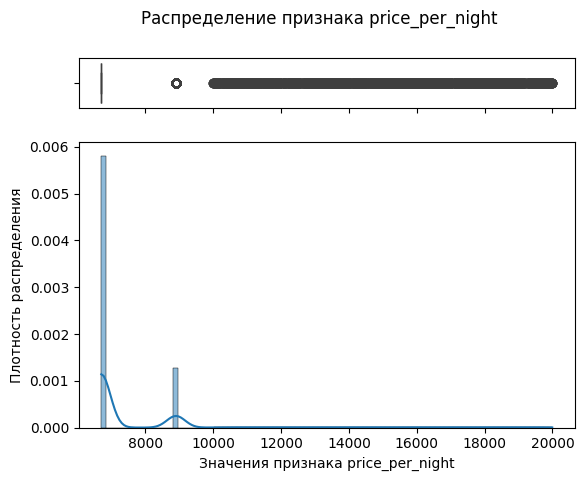

In [47]:
eda_helper.box_hist(df, 'price_per_night', bins=100)

Значения за ночь собраны вокруг трех точек. Остальные стоимости ночи распределены почти равномерно по 1-3 значениям.


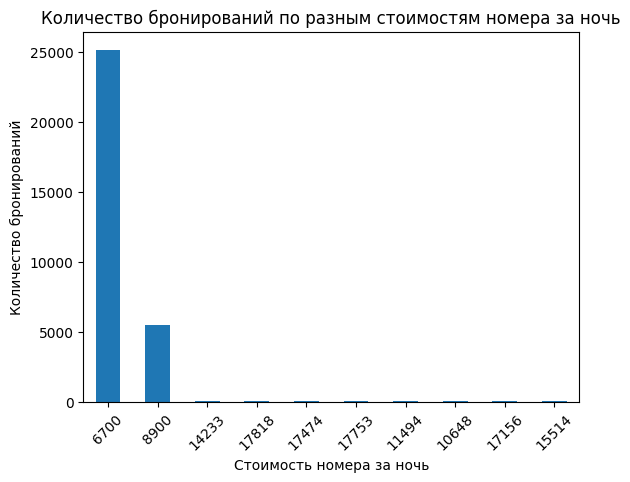

In [48]:
df_price_per_night = df['price_per_night'].value_counts().head(10)
df_price_per_night.index = df_price_per_night.index.round(0).astype(int)
df_price_per_night.plot(
    kind='bar',
    title='Количество бронирований по разным стоимостям номера за ночь',
    xlabel='Стоимость номера за ночь',
    ylabel='Количество бронирований',
    rot=45,
)
plt.show()

Больше всего (25к) бронирований за 6700 рублей, чуть меньше (5к) за 8900 рублей, около 1000 бронирований за 0 рублей. 

Гипотеза подобного поведения следующая:
- нулевые стоимости могут означать бонусное заселение (по промокоду или с помощью других промо-механик)
- цены сгруппированы вокруг стоимости за ночь в рабочий день и стоимости за ночь в выходной день


Первую гипотезу проверить не представляется возможным, поэтому просто оставим эти записи с нулевой стоимостью за ночь в датасете. Нас интересует вероятность отмены бронирования, поэтому данные объекты представляют интерес так же как и другие.

Проверим вторую гипотезу, сгруппировав количество записей по разным ценам только для объектов с бронированием в рабочие дни:

In [49]:
df_tmp = df[(df['weekend_nights'] == 0)]
df_tmp['ppn'] = df_tmp['booking_value'] / df['weekday_nights']
df_tmp['ppn'].value_counts().head(10)

ppn
6700.000000     6336
8900.000000     1363
17752.950000       3
10648.033333       3
17215.960000       2
15855.266667       2
14767.400000       2
18558.340000       2
17098.050000       2
14807.820000       2
Name: count, dtype: int64

Гипотеза не подтвердилась: в рабочие дни примерно такое же распределение цен за номера. Тогда можно предположить, что стоимость сгруппирована вокруг разных классов номеров.

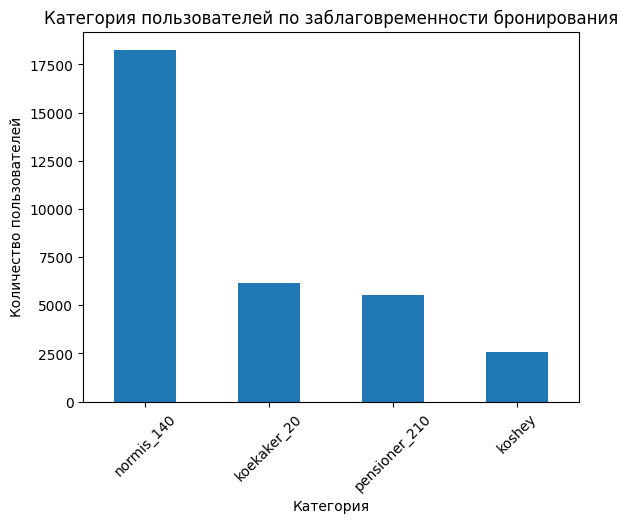

In [50]:
df['days_until_checkin_cat'].value_counts().plot(
    kind='bar',
    title='Категория пользователей по заблаговременности бронирования',
    xlabel='Категория',
    ylabel='Количество пользователей',
    rot=45,
)
plt.show()

Больше всего нормальных людей, которые бронируют за 20-140 дней. Следом идут коекакеры, которые бронируют в срок до 20 дней. Примерно столько же пенсионеров и кощеев, которые бронируют больше чем за пол года (знают, что с ними будет!)

Исследуем признаки сезонности:

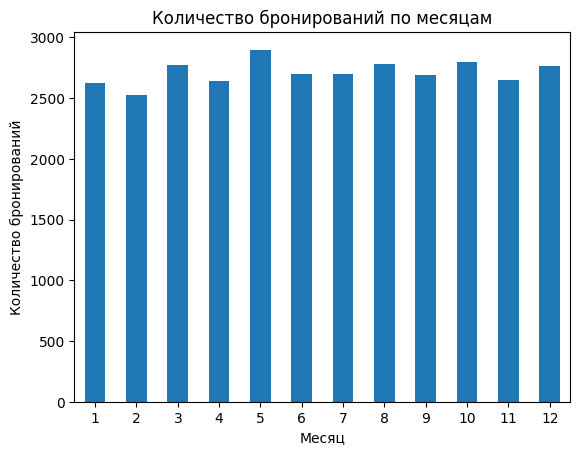

In [51]:

df.groupby(['checkin_month']).agg({'booking_id': 'count'}).reset_index().plot(
    kind='bar',
    x='checkin_month',
    y='booking_id',
    ylabel="Количество бронирований",
    title = 'Количество бронирований по месяцам',
    xlabel = 'Месяц',
    legend=False,
    rot=0
)
plt.show()

Больше всего забронировано номеров на checkin в мае: связанно вероятно с длинными майскими праздниками. Спад сезона в феврале и ноябре согласуется с ожиданиями. Немного странно выглядят низкие показатели количества бронирований в июне и июле, но это особенность данных.

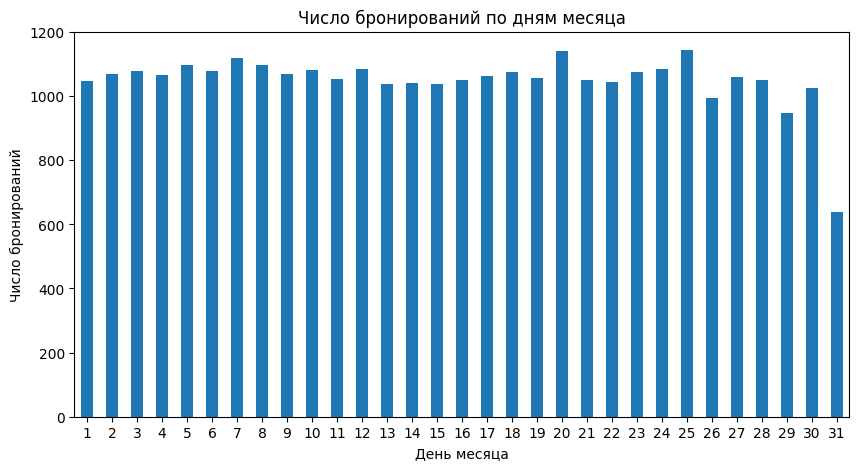

In [52]:
df.groupby(['checkin_day_of_month']).agg({'booking_id': 'count'}).reset_index() \
    .plot(
        kind='bar',
        x = 'checkin_day_of_month',
        title='Число бронирований по дням месяца',
        y = 'booking_id',
        ylabel='Число бронирований',
        xlabel='День месяца',
        rot=0,
        figsize=(10, 5),
        legend=False,
    )
plt.show()

По графику сезонность по дням месяца не прослеживается. Спад 31 числа связан, очевидно, с меньшим количеством дней в году с этим номером 

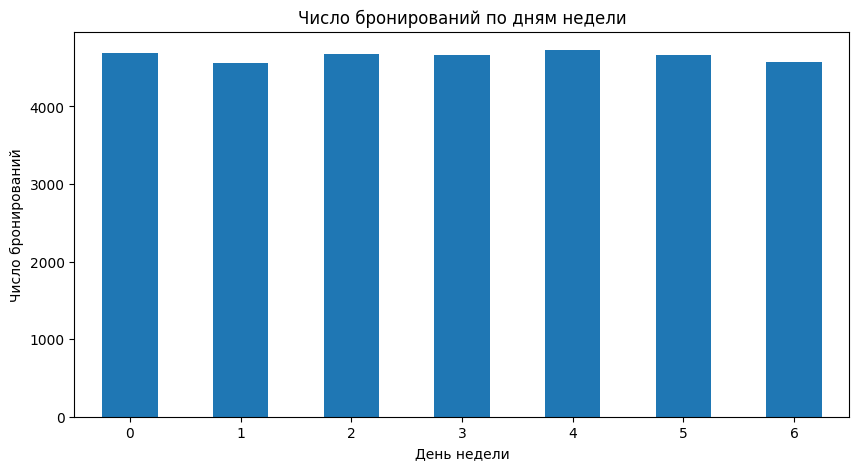

In [53]:
df.groupby(['checkin_day_of_week']).agg({'booking_id': 'count'}).reset_index() \
    .plot(
        kind='bar',
        x = 'checkin_day_of_week',
        title='Число бронирований по дням недели',
        y = 'booking_id',
        ylabel='Число бронирований',
        xlabel='День недели',
        # ylim=(4500),
        rot=0,
        figsize=(10, 5),
        legend=False,
    )
plt.show()

На пятницу больше всего заездов - это логично, посетители заезжают на вызные. Но в целом отличия незначительные.

<font color='blue'><b>Комментарий ревьюера : </b></font> ⚠️\
<font color='darkorange'> Анализ count не учитывает тренда и шума в данных.\
Данные с более высокими значениями смещают агрегаты.\
Нужно разложить ряд на компоненты с `seasonal_decompose`\
`statsmodels.tsa.seasonal.seasonal_decompose`</font>

#### Разделение датасета на выборки

Для создания признаков на основе тестов, необходимо произвести векторизацию текстовых данных на тренировочном датасете. Предварительно разделим датасет на выборки на train/val/test.
- Трейн в дальнейшем будет использован через кросс валидацию с помощью TimeSeriesSplit для обучения модели.
- Вал будет использован для калибровки
- Тест - это отложенная выборка на которой проверяется финальная модель и ее метрики качества

Так как мы используем кросс-валидацию, то векторизация признаков будет производится внутри пайплайна обучения модели для избегания утечки данных.

В данном разделе выполним предварительную "исследовательскую векторизацию" текстовых данных для проверки механизма векторизации и получаемых признаков.

In [54]:
# Сортируем по дате букинга перед удалением колонки с датой:
df = df.sort_values('booking_date').reset_index(drop=True)

Теперь разделим датасет на обучающую, валидационную (калибровочную в нашем случае) и тестовую выборки с сохранением последовательности временного ряда.

In [55]:
# определяем точку для разделения по пропорциям - трейн - 60%, вал/тест - 40%
split_point = int(len(df) * 0.6)
train_data_df = df.iloc[:split_point]
val_test_data_df = df.iloc[split_point:]

# определяем точку для разделения по пропорциям - вал - 50%, тест - 50%
split_point = int(len(val_test_data_df) * 0.5)
val_data_df = val_test_data_df.iloc[:split_point]
test_data_df = val_test_data_df.iloc[split_point:]

# Удаляем служебные столбцы, выделяем матрицу признаков и целевую переменную для всех выборок:
def get_X_y(df, columns_to_drop=[], target_col_name=TARGET_COL_NAME):
    X = df.drop(columns=columns_to_drop + [target_col_name])
    y = df[target_col_name]
    return X, y

col_to_drop = [
    'booking_id',
    'customer_id',
    'review_date',
    'booking_date',
    'checkin_date',
]

X_train, y_train = get_X_y(train_data_df, col_to_drop)
X_val, y_val = get_X_y(val_data_df, col_to_drop)
X_test, y_test = get_X_y(test_data_df, col_to_drop)

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'>Выборки идут в нужной последовательности.</font>

<font color='blue'><b>Комментарий ревьюера : </b></font> ⚠️\
<font color='darkorange'>Для этого можно применять `train_test_split`, но отключить перемешивание и стратификацию.</font>

Определим класс для удобного применения единообразных операций ко всем трем выборках.

In [56]:
class Xy:
    def __init__(self, X, y):
        self.X = X
        self.y = y

class DatasetHolder:
    def __init__(self, X_train, X_val, X_test, y_train, y_val, y_test):
        self.train = Xy(X_train, y_train)
        self.val = Xy(X_val, y_val)
        self.test = Xy(X_test, y_test)

    def foreachX(self, func):
        results = []
        for x in [self.train.X, self.val.X, self.test.X]:
            result = func(x)
            if result is not None:
                results.append(result)
        return tuple(results)



ds_holder = DatasetHolder(X_train, X_val, X_test, y_train, y_val, y_test)

#### Векторизация отзывов

Используем Tf-IDF для преобразования текстовых данных в числовые на трейн выборке:

Очистка текстовых данных:

In [57]:
# Выполним предобработку текста:

russian_stopwords = set(stopwords.words('russian'))

# функция очистки окончаний (пока не используется)
def remove_endings(text):
    if text is np.nan:
        return text
    russian_endings = {
        'ый','ий','ой','ое','ее','ая','яя','ые','ие',
        'ой','ей','ых','их','ом','ем','ой','ей',
    }
    if text[-2:] in russian_endings:
        text = text[:-2]
    return text

# Функция очистки стоп-слов и окончаний
def remove_stopwords(text_tokens):
    if text_tokens is np.nan or text_tokens is None:
        return ''
    filtered_sentence = []

    for token in text_tokens:
        # token = remove_endings(token)

        if token not in russian_stopwords:
            filtered_sentence.append(token)

    return " ".join(filtered_sentence)


def clear_text(df, col_name):
    df['review_text_filtered'] = df[col_name].str.replace(r'[^\w\s]|[\s]+', ' ', regex=True)  # заменим все спец символы и лишние пробелы на один пробел
    df['review_text_filtered'] = df['review_text_filtered'].str.strip()  #  удалить все переносы строк
    df['review_text_filtered'] = df['review_text_filtered'].str.lower()  #  перевести тексты в нижний регистр
    df['tokens'] = df['review_text_filtered'].str.split()
    df['filtered_text'] = df['tokens'].apply(remove_stopwords)
    df.drop(columns=['tokens', 'review_text_filtered'], inplace=True)
    df['filtered_text'].fillna('', inplace=True)

ds_holder.foreachX(lambda df: clear_text(df, 'review_text'))

# Сбрасываем индексы, чтобы избежать появления NaN при объединении
ds_holder.foreachX(lambda df: df.reset_index(drop=True))

print('Таблица с преобразованными текстами:')
display(X_train[X_train['filtered_text'].str.len() > 0].head(3))
print('Таблица с пустым тектом:')
display(X_train.head(3))


Таблица с преобразованными текстами:


/var/folders/qy/vrhgk4653zx3pp81pb5hn8500000gn/T/ipykernel_65894/2913737496.py:39: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['filtered_text'].fillna('', inplace=True)


,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests,stay_rating,review_text,nights_num,price_per_night,days_until_checkin_cat,checkin_month,checkin_day_of_month,checkin_day_of_week,filtered_text
2608,корпоративное_бронирование,3,1,True,1,2,60300.0,3,7,2,тип_питания_1,False,тип_4,0,2.0,"Крайне недоволен. холодная еда в ресторане. завышенные цены при низком уровне сервиса Для детей ничего нет, им было скучно. В номерах холодно. второго одеяла пришлось выпрашивать",9,6700.0,koekaker_20,7,12,2,крайне недоволен холодная еда ресторане завышенные цены низком уровне сервиса детей скучно номерах холодно второго одеяла пришлось выпрашивать
2706,корпоративное_бронирование,1,0,True,0,2,33500.0,80,5,0,тип_питания_1,False,тип_1,1,4.0,Отличный отель! всё супер. лучший отель в этом городе — это факт! Зимой отель хорошо отапливается.,5,6700.0,normis_140,10,4,2,отличный отель всё супер лучший отель городе это факт зимой отель отапливается
2730,офлайн_бронирование,2,1,True,0,2,80100.0,197,7,2,тип_питания_1,False,тип_6,0,4.0,Отличный отель! отличная шумоизоляция. здесь ценят гостей — это чувствуется Дети в восторге от игровой зоны! Зимой отель хорошо отапливается.,9,8900.0,pensioner_210,1,31,2,отличный отель отличная шумоизоляция ценят гостей это чувствуется дети восторге игровой зоны зимой отель отапливается


Таблица с пустым тектом:


,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests,stay_rating,review_text,nights_num,price_per_night,days_until_checkin_cat,checkin_month,checkin_day_of_month,checkin_day_of_week,filtered_text
0,онлайн_бронирование,3,2,False,0,0,67000.0,124,8,2,тип_питания_2,False,тип_2,0,NaN,NaN,10,6700.0,normis_140,5,5,4,
1,онлайн_бронирование,3,0,False,0,0,89000.0,85,8,2,тип_питания_1,False,тип_1,1,NaN,NaN,10,8900.0,normis_140,3,27,0,
2,онлайн_бронирование,3,0,True,1,1,46900.0,83,5,2,тип_питания_1,False,тип_1,2,NaN,NaN,7,6700.0,normis_140,3,25,5,


Удаляем столбцец с сырыми данными:

In [58]:
X_train, X_val, X_test = ds_holder.foreachX(lambda x: x.drop(columns=['review_text']))

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'>Очистка сделана верно! Мы оставили только символы алфавита и привели к нижнему регистру!\
Убрали частые неинформативные слова!</font>

In [59]:
def tfidf():
    return TfidfVectorizer(
        lowercase=True,    # приводить текст к нижнему регистру
        analyzer='word',   # анализировать текст по словам
        token_pattern=r'(?u)\b\w\w+\b',  # токен = слово из 2+ символов
        stop_words=None,   # стоп-слова не удаляем  (список или 'english')
        ngram_range=(1, 1),# использовать только униграммы
        min_df=1,          # минимальная частота документа для терма
        max_df=1.0,        # максимальная доля документов для терма
        use_idf=True,      # использовать IDF-взвешивание
        smooth_idf=True,   # сглаживать IDF
        sublinear_tf=False,# не применять log-масштабирование TF
        norm='l2'          # L2-нормализация векторов
    )
class Vectorizer(BaseEstimator, TransformerMixin):
    def __init__(self, text_col_name = 'filtered_text'):
        self.text_col_name = text_col_name
        self.non_vec_cols = []
        self.vec_cols = []
        self.vectorizer = tfidf()

    def fit(self, X, y=None):
        # Обучение на трейне и трансформация остальных выборок
        self.vectorizer.fit(X[self.text_col_name])
        return self

    def transform(self, X):
        x_sparse = self.vectorizer.transform(X[self.text_col_name])

        vec_feature_names = [f"vec_{name}" for name in self.vectorizer.get_feature_names_out()]

        # Соединим веркторизированные тексты (признаки) с основным датасетом:
        # Переводим в DataFrame с правильными индексами
        x_vec_df = pd.DataFrame.sparse.from_spmatrix(x_sparse, columns=vec_feature_names, index=X.index)

        # Удаляем исходный текст, чтобы он не мешал базовым алгоритмам
        x_features_wo_text = X.drop(columns=[self.text_col_name])

        # Объединяем основные признаки с векторизированными текстами
        x_final = pd.concat([x_features_wo_text, x_vec_df], axis=1)

        # Преобразуем веркторизированные данные к float32 из float64 для экономии памяти и заполним
        x_final = x_final.astype({col: 'float32' for col in vec_feature_names})

        self.vec_cols = [col for col in x_final.columns if col.startswith('vec_')]
        self.non_vec_cols = [col for col in x_final.columns if not col.startswith('vec_')]

        return x_final

    def get_non_vec_cols(self):
        return self.non_vec_cols

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'>~~Здесь не последнее разбиение на выборки. Для корректной кросс-валидации, Всю предобработку (Кодирование, векторизацию) нужно объединить с обучением моделей классификации через Pipeline, для избегания утечек между обучающими и валидационными подвыборками. Или повторять в цикле кросс-валидации для  X_train.iloc[train_idx] и X_train.iloc[val_idx].~~</font>

</span><br><span style="color: purple; font-weight: bold"> ✅ Комментарий студента № 1: переписал векторизацию, встроив ее в пайплайн для избежания утечки данных</span>


<span style="color: blue; font-weight:">Комментарий ревьюера 2: </span> ✔️\
<span style="color: green"> 👍</span>

Обучим векторизатор (обучение в тестовом режиме, при кросс-валидации будет создан новый объект векторизатор):

In [60]:
vectorizer = Vectorizer()
vectorizer.fit(X_train)
X_train_vectorized = vectorizer.transform(X_train)
X_train_vectorized.sample(10, random_state=RANDOM_STATE)

,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests,stay_rating,nights_num,price_per_night,days_until_checkin_cat,checkin_month,checkin_day_of_month,checkin_day_of_week,vec_администрация,vec_аккуратный,vec_аромат,vec_атмосфера,vec_атмосферой,vec_аэропорта,vec_багажа,vec_базовых,vec_бар,vec_бассейн,vec_бассейне,vec_безопасности,vec_бельё,vec_беспокоился,vec_близко,vec_болела,vec_бонусы,vec_бронировании,vec_бронировать,vec_буду,vec_быстрая,vec_быстро,vec_быстрый,vec_ванной,vec_вдали,vec_вежливый,vec_вентиляция,vec_вернусь,vec_вещи,vec_вид,vec_виды,vec_визитная,vec_включён,vec_вкусный,vec_влюбил,vec_внимательный,vec_водой,vec_воды,vec_возвращаться,vec_возникли,vec_восторге,vec_впечатляет,vec_время,vec_всем,vec_всё,vec_второго,vec_входа,vec_входу,vec_выбор,vec_выпрашивать,vec_высоте,vec_высшем,vec_выше,vec_главная,vec_говорит,vec_города,vec_городе,vec_горячей,vec_гостей,vec_гость,vec_грубый,vec_грязные,vec_далеко,vec_дарит,vec_делает,vec_день,vec_детей,vec_дети,vec_дизайн,vec_дней,vec_дня,vec_долгий,vec_долгое,vec_дом,vec_дома,vec_дорого,vec_доставка,vec_достаточное,vec_дружелюбная,vec_друзьям,vec_душа,vec_душно,vec_еда,vec_еды,vec_ещё,vec_жалобы,vec_жарко,vec_жары,vec_ждут,vec_желать,vec_забота,vec_заботой,vec_заботу,vec_забронирую,vec_заверения,vec_завтрак,vec_завышенные,vec_заказа,vec_зале,vec_запах,vec_запомнился,vec_заселения,vec_заселили,vec_заявленным,vec_звукоизоляция,vec_звёздам,vec_зимой,vec_знает,vec_знакомым,vec_зона,vec_зонах,vec_зоны,vec_игнорирует,vec_игровой,vec_идеал,vec_идеальный,vec_интернет,vec_интерьер,vec_искусство,vec_испытать,vec_история,vec_каждый,vec_карточка,vec_качества,vec_качественная,vec_качественное,vec_качественные,vec_ковры,vec_компромиссов,vec_комфорта,vec_комфортабельные,vec_комфортные,vec_кондиционер,vec_кондиционирования,vec_коридора,vec_коридоре,vec_косметика,vec_который,vec_крайне,vec_красивое,vec_красивый,vec_кровати,vec_летом,vec_лифт,vec_лифты,vec_личном,vec_лобби,vec_лучшего,vec_лучший,vec_любовь,vec_максимум,vec_мало,vec_матрасы,vec_мебель,vec_медленное,vec_медленный,vec_меню,vec_меняли,vec_меняю,vec_мест,vec_места,vec_место,vec_мешают,vec_мини,vec_моим,vec_моих,vec_моём,vec_музыка,vec_мусор,vec_мыться,vec_надёжная,vec_насекомые,vec_находиться,vec_небезопасные,vec_небезопасный,vec_недоволен,vec_недостаточная,vec_недостаточное,vec_незабываемым,vec_неисправная,vec_некомпетентный,vec_некомфортная,vec_некомфортные,vec_неплохо,vec_непонятная,vec_неприятно,vec_неприятный,vec_неработающий,vec_несвежие,vec_несколько,vec_несмотря,vec_несоответствие,vec_неубранный,vec_неудачное,vec_неудачный,vec_неудобная,vec_неудобно,vec_неудобное,vec_неудобные,vec_неудобный,vec_нехватка,vec_низком,vec_новые,vec_новыми,vec_номер,vec_номера,vec_номерах,vec_номере,vec_номеров,vec_ночью,vec_нужно,vec_обещали,vec_обещанные,vec_обманули,vec_оборудования,vec_обслуживание,vec_обслуживанием,vec_общественных,vec_обязательно,vec_ого,vec_одеяла,vec_однозначно,vec_однообразный,vec_ожидание,vec_ожидания,vec_окон,vec_оперативное,vec_описанием,vec_оплаты,vec_освещена,vec_освещение,vec_особенный,vec_особенным,vec_оставляет,vec_останавливаюсь,vec_остановлюсь,vec_отапливается,vec_отдельная,vec_отдых,vec_отдыха,vec_отеле,vec_отель,vec_отеля,vec_открыть,vec_отличная,vec_отлично,vec_отличные,vec_отличный,vec_отпуск,vec_отсутствие,vec_официанты,vec_оформление,vec_оценить,vec_очень,vec_очереди,vec_ощущение,vec_парковка,vec_парковки,vec_парковочные,vec_пахнет,vec_первого,vec_перебои,vec_персонал,vec_платежи,vec_плесень,vec_плохая,vec_плохо,vec_плохое,vec_подушки,vec_пожалеете,vec_покорил,vec_пол,vec_полотенец,vec_полотенца,vec_пользоваться,vec_порядок,vec_постельное,vec_потёртые,vec_похвал,vec_почувствовать,vec_праздника,vec_пребывания,vec_превзошли,vec_превзошёл,vec_превосходно,vec_предоставили,vec_прекрасный,vec_премиум,vec_приветливые,vec_приветливый,vec_приеду,v

<span style="color: blue; font-weight:">Комментарий ревьюера 2: </span> ✔️\
<span style="color: green"> 👍</span>

Признаки векторизированного текста заполнены. Метод векторизации работает корректно. Векторизация добавляет 444 новых признака в матрицу признаков по числу слов в словаре.

### Анализ итоговой таблицы

Проверим содержимое таблицы признаков и типы без векторизированных текстовых признаков:

In [61]:
eda_helper.df_info(X_train_vectorized[vectorizer.get_non_vec_cols()])

--------------------------------------------------
Описание датасета :
Датасет  содержит 19519 строк и 21 столбцов.
Размер датасета  в памяти: 2.23 MB
--------------------------------------------------
Данные датасета :
--------------------------------------------------


,place,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests,stay_rating,nights_num,price_per_night,days_until_checkin_cat,checkin_month,checkin_day_of_month,checkin_day_of_week
0,head,онлайн_бронирование,3,2,False,0,0,67000.0,124,8,2,тип_питания_2,False,тип_2,0,NaN,10,6700.0,normis_140,5,5,4
1,head,онлайн_бронирование,3,0,False,0,0,89000.0,85,8,2,тип_питания_1,False,тип_1,1,NaN,10,8900.0,normis_140,3,27,0
2,head,онлайн_бронирование,3,0,True,1,1,46900.0,83,5,2,тип_питания_1,False,тип_1,2,NaN,7,6700.0,normis_140,3,25,5
385,random,корпоративное_бронирование,2,1,False,0,0,73700.0,11,9,2,тип_питания_2,False,тип_4,0,NaN,11,6700.0,koekaker_20,2,11,5
9022,random,корпоративное_бронирование,1,0,True,0,1,67000.0,7,8,2,тип_питания_1,False,тип_2,1,NaN,10,6700.0,koekaker_20,7,31,1
12513,random,онлайн_бронирование,2,0,False,0,0,124600.0,123,10,4,тип_питания_1,False,тип_4,0,NaN,14,8900.0,normis_140,5,14,1
19516,tail,онлайн_бронирование,2,0,False,1,0,17800.0,121,2,0,тип_питания_2,False,тип_1,1,NaN,2,8900.0,normis_140,3,31,1
19517,tail,корпоративное_бронирование,2,0,False,0,0,26700.0,18,3,0,тип_питания_1,False,тип_1,1,NaN,3,8900.0,koekaker_20,12,19,3
19518,tail,офлайн_бронирование,1,1,False,0,0,13400.0,7,2,0,тип_питания_2,False,тип_1,1,NaN,2,6700.0,koekaker_20,12,8,6


--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 19519 entries, 0 to 19518
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   sales_channel              19519 non-null  category
 1   adult_count                19519 non-null  int64   
 2   child_count                19519 non-null  int64   
 3   returning_customer         19519 non-null  bool    
 4   previous_cancellations     19519 non-null  int64   
 5   previous_no_shows          19519 non-null  int64   
 6   booking_value              19519 non-null  float64 
 7   days_until_checkin         19519 non-null  int64   
 8   weekday_nights             19519 non-null  int64   
 9   weekend_nights             19519 non-null  int64   
 10  meal_plan                  19519 non-null  category
 11  parking_included           19519 non-null  bool    
 12  room_type                  19519 non-null  categ

,index,Количество строк,Количество пропусков,Процент пропусков
0,stay_rating,19519,16094,82.5


Все кат фичи имеют корректный тип category, необходимый моделям для специальной обработки категориальных данных. Пропуски в stay_rating будут заполнены специальным значением в пайплайне. Дополнительные преобразования не требуются.

Исследуем полную матрицу признаков с векторизированными данными:

In [62]:
eda_helper.df_info(X_train_vectorized, 'train')

--------------------------------------------------
Описание датасета train:
Датасет train содержит 19519 строк и 465 столбцов.
Размер датасета train в памяти: 36.89 MB
--------------------------------------------------
Данные датасета train:
--------------------------------------------------


/var/folders/qy/vrhgk4653zx3pp81pb5hn8500000gn/T/ipykernel_65894/1952145603.py:269: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.sample(n_samples, random_state=RANDOM_STATE).assign(place='random'),
/var/folders/qy/vrhgk4653zx3pp81pb5hn8500000gn/T/ipykernel_65894/1952145603.py:274: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sample_df.insert(0, last_col.name, last_col)


,place,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests,stay_rating,nights_num,price_per_night,days_until_checkin_cat,checkin_month,checkin_day_of_month,checkin_day_of_week,vec_администрация,vec_аккуратный,vec_аромат,vec_атмосфера,vec_атмосферой,vec_аэропорта,vec_багажа,vec_базовых,vec_бар,vec_бассейн,vec_бассейне,vec_безопасности,vec_бельё,vec_беспокоился,vec_близко,vec_болела,vec_бонусы,vec_бронировании,vec_бронировать,vec_буду,vec_быстрая,vec_быстро,vec_быстрый,vec_ванной,vec_вдали,vec_вежливый,vec_вентиляция,vec_вернусь,vec_вещи,vec_вид,vec_виды,vec_визитная,vec_включён,vec_вкусный,vec_влюбил,vec_внимательный,vec_водой,vec_воды,vec_возвращаться,vec_возникли,vec_восторге,vec_впечатляет,vec_время,vec_всем,vec_всё,vec_второго,vec_входа,vec_входу,vec_выбор,vec_выпрашивать,vec_высоте,vec_высшем,vec_выше,vec_главная,vec_говорит,vec_города,vec_городе,vec_горячей,vec_гостей,vec_гость,vec_грубый,vec_грязные,vec_далеко,vec_дарит,vec_делает,vec_день,vec_детей,vec_дети,vec_дизайн,vec_дней,vec_дня,vec_долгий,vec_долгое,vec_дом,vec_дома,vec_дорого,vec_доставка,vec_достаточное,vec_дружелюбная,vec_друзьям,vec_душа,vec_душно,vec_еда,vec_еды,vec_ещё,vec_жалобы,vec_жарко,vec_жары,vec_ждут,vec_желать,vec_забота,vec_заботой,vec_заботу,vec_забронирую,vec_заверения,vec_завтрак,vec_завышенные,vec_заказа,vec_зале,vec_запах,vec_запомнился,vec_заселения,vec_заселили,vec_заявленным,vec_звукоизоляция,vec_звёздам,vec_зимой,vec_знает,vec_знакомым,vec_зона,vec_зонах,vec_зоны,vec_игнорирует,vec_игровой,vec_идеал,vec_идеальный,vec_интернет,vec_интерьер,vec_искусство,vec_испытать,vec_история,vec_каждый,vec_карточка,vec_качества,vec_качественная,vec_качественное,vec_качественные,vec_ковры,vec_компромиссов,vec_комфорта,vec_комфортабельные,vec_комфортные,vec_кондиционер,vec_кондиционирования,vec_коридора,vec_коридоре,vec_косметика,vec_который,vec_крайне,vec_красивое,vec_красивый,vec_кровати,vec_летом,vec_лифт,vec_лифты,vec_личном,vec_лобби,vec_лучшего,vec_лучший,vec_любовь,vec_максимум,vec_мало,vec_матрасы,vec_мебель,vec_медленное,vec_медленный,vec_меню,vec_меняли,vec_меняю,vec_мест,vec_места,vec_место,vec_мешают,vec_мини,vec_моим,vec_моих,vec_моём,vec_музыка,vec_мусор,vec_мыться,vec_надёжная,vec_насекомые,vec_находиться,vec_небезопасные,vec_небезопасный,vec_недоволен,vec_недостаточная,vec_недостаточное,vec_незабываемым,vec_неисправная,vec_некомпетентный,vec_некомфортная,vec_некомфортные,vec_неплохо,vec_непонятная,vec_неприятно,vec_неприятный,vec_неработающий,vec_несвежие,vec_несколько,vec_несмотря,vec_несоответствие,vec_неубранный,vec_неудачное,vec_неудачный,vec_неудобная,vec_неудобно,vec_неудобное,vec_неудобные,vec_неудобный,vec_нехватка,vec_низком,vec_новые,vec_новыми,vec_номер,vec_номера,vec_номерах,vec_номере,vec_номеров,vec_ночью,vec_нужно,vec_обещали,vec_обещанные,vec_обманули,vec_оборудования,vec_обслуживание,vec_обслуживанием,vec_общественных,vec_обязательно,vec_ого,vec_одеяла,vec_однозначно,vec_однообразный,vec_ожидание,vec_ожидания,vec_окон,vec_оперативное,vec_описанием,vec_оплаты,vec_освещена,vec_освещение,vec_особенный,vec_особенным,vec_оставляет,vec_останавливаюсь,vec_остановлюсь,vec_отапливается,vec_отдельная,vec_отдых,vec_отдыха,vec_отеле,vec_отель,vec_отеля,vec_открыть,vec_отличная,vec_отлично,vec_отличные,vec_отличный,vec_отпуск,vec_отсутствие,vec_официанты,vec_оформление,vec_оценить,vec_очень,vec_очереди,vec_ощущение,vec_парковка,vec_парковки,vec_парковочные,vec_пахнет,vec_первого,vec_перебои,vec_персонал,vec_платежи,vec_плесень,vec_плохая,vec_плохо,vec_плохое,vec_подушки,vec_пожалеете,vec_покорил,vec_пол,vec_полотенец,vec_полотенца,vec_пользоваться,vec_порядок,vec_постельное,vec_потёртые,vec_похвал,vec_почувствовать,vec_праздника,vec_пребывания,vec_превзошли,vec_превзошёл,vec_превосходно,vec_предоставили,vec_прекрасный,vec_премиум,vec_приветливые,vec_приветливый,vec_пр

--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 19519 entries, 0 to 19518
Columns: 465 entries, sales_channel to vec_языке
dtypes: bool(2), category(4), float32(444), float64(3), int32(3), int64(9)
memory usage: 35.2 MB
None


,index,Количество строк,Количество пропусков,Процент пропусков
0,vec_душно,19519,19518,100.0
1,vec_пахнет,19519,19518,100.0
2,vec_бассейне,19519,19518,100.0
3,vec_мешают,19519,19518,100.0
4,vec_мыться,19519,19518,100.0
...,...,...,...,...
440,vec_кондиционер,19519,18566,95.1
441,vec_отличный,19519,18201,93.2
442,vec_отель,19519,18137,92.9
443,vec_неплохо,19519,17470,89.5


Часть матрицы признаков векторизованных текстов ожидаемо имеет значительную разреженность. 

Все пропуски будут заменены на специальные значения в пайплайне. Можно приступать к моделированию.

<a id="modeling"></a>

## Этап 2: моделирование

### Обучение и оптимизация модели

- Выберите и обучите не менее двух моделей из списка:

  - Random Forest;

  - CatBoost;

  - LightGBM;

  - XGBoost;

  - любую другую на ваш выбор.

- Разделите данные на три выборки:
  - Обучающую — для обучения моделей (60% данных);
  - Калибровочную — для проведения калибровки модели (20% данных);
  - Тестовую — для финальной оценки качества выбранной модели (20% данных).

- Проведите кросс-валидацию, используйте три фолда. Размер выборки для валидации — 2000.

- Оптимизируйте гиперпараметры с помощью Optuna. Количество гиперпараметров — не менее трёх. Ключевая метрика для оптимизации — Incremental Revenue.

- Сделайте выводы о том, какая модель показала лучшие результаты.

Разделение датасета на трейн/вал/тест выборки было прозиведено в предыдущем разделе. Сформируем пайплайны для обучения базовых версий моделей. 

Специального преобразования категориальных признаков не требуется, так как используемые модели умеют их обрабатывать "из коробки".

Пропуски также обработаны ранее. В данном ноутбуке производится только исследование возможностей МЛ моделей для улучшения бизнес-показателей по отказам от бронирования и не предполагается внедрение модели в производственный процесс в рантайме, поэтому весь процесс по предобработке проведен ранее и не делается внутри пайплайнов.

При положительном исходе исследования лучшие модели вместе с предобработчиками данных могут быть преобразованы упакованы в персистентную сущность для применения в проде. На данном этапе такую задачу перед собой не ставим.

#### Метрики качества модели

Определим метрики, по которым будем производить сравнение моделей.

In [63]:
# Доход получен как среднее по фактам бронирования и по всем типам номеров (посчитан заранее)
AvgRev = 64500
# В эту сумму входят компенсация гостю, административные затраты, маркетинговые издержки.
CostFP = 7000
LostRev = 64500
# стоимость повторной сдачи номеров, бронь на которые отменилась
PerRebooking = 45000


def incremental_revenue_before(y_true):
    '''
    Подсчитывает выручку до внедрения модели по формуле
    IR_до​=(TotalSuccess×AvgRev)−(TotalCancellations×LostRev)

    Где
    - TotalSuccess — все успешные брони, которые состоялись и были оплачены.
    - AvgRev — средний доход от сдачи одного номера.
    - TotalCancellations — все отмены бронирования.
    - LostRev — упущенный доход от отмены одного бронирования. Равен AvgRev, если нет других факторов
    '''
    total_success = y_true[y_true == 0].count()
    total_cancellations = y_true.sum()
    return total_success * AvgRev - total_cancellations * LostRev

y_true_test = pd.Series([0, 1, 0])
y_pred_test = pd.Series([0, 1, 1])
assert incremental_revenue_before(y_true_test) == 64500

def incremental_revenue_after(y_true, y_pred):
    '''
    Подсчитывает выручку после внедрения модели по формуле
    (TP×PerRebooking)+(TN×AvgRev)−(FP×CostFP)−(FN×LostRev)

    Где
    - TP — верно предсказанные отмены бронирования.
    - PerRebooking — стоимость повторной сдачи номеров, бронь на которые отменилась. Вовремя замеченная отмена даёт возможность сдать номер кому-то другому, это обеспечивает дополнительную прибыль.
    - TN — количество случаев, когда модель не предсказала отмены и бронь действительно состоялась, гость вовремя заехал и оплатил номер.
    - FP — ложные отмены бронирования — модель предсказала отмену, но гости приехали.
    - CostFP — стоимость одного ложного предсказания отмены бронирования, компенсации, ущерб от потери лояльности, административные издержки.
    - FN — пропущенные отмены — модель не предсказала отмену, но она произошла.
    '''
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return (tp * PerRebooking) + (tn * AvgRev) - (fp * CostFP) - (fn * LostRev)

assert incremental_revenue_after(y_true_test, y_pred_test) == 102500

def incremental_revenue(y_true, y_pred):
    '''
    Подсчитывает разницу между выручкой до и после внедрения модели по формуле
    IR_после​−IR_до
    '''
    return incremental_revenue_after(y_true, y_pred) - incremental_revenue_before(y_true)

assert incremental_revenue(y_true_test, y_pred_test) == 38000

def incremental_revenue_relative_diff(y_true, y_pred):
    '''
    Подсчитывает относительную разницу между выручкой до и после внедрения модели по формуле
    (IR_после​−IR_до) / IR_до
    '''
    return incremental_revenue(y_true, y_pred) / incremental_revenue_before(y_true) * 100

relative_diff = round(incremental_revenue_relative_diff(y_true_test, y_pred_test), 2)
expected_relative_diff = 58.91
assert relative_diff == expected_relative_diff, f'{relative_diff} != {expected_relative_diff}'

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<font color='green'>Расчёт incremental revenue (IR) верный.</font>

<span style="color: blue;: bold">Комментарий ревьюера : </span> ⚠️\
<font color='darkorange'>Константы можно вынести в начало модуля</font>

In [64]:
def cancellation_rate_before(y_true):
    '''
    Подсчитывает долю отмен по формуле
    Доля отмен = Количество отмен / Количество броней
    '''
    return y_true.mean()

def cancellation_rate_after(y_true, y_pred):
    '''
    Подсчитывает долю отмен по формуле
    Доля отмен = Количество РЕАЛЬНЫХ отмен / Количество броней
    Где Количество РЕАЛЬНЫХ отмен == количество FN модели, то есть там где
    модель посчитала что отмены не будет, а она случилась.
    TP не учитывается в формуле, так как модель предсказала отмену и
    отель имеет возможность заселить в освободившийся номер нового клиента.
    '''
    _, _, fn, _ = confusion_matrix(y_true, y_pred).ravel()
    return fn/len(y_true)

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'>~~Стандартный .ravel() от confusion_matrix возвращает порядок: tn, fp, fn, tp.~~</font>

</span><br><span style="color: purple; font-weight: bold"> ✅ Комментарий студента № 1: исправлено</span>

<span style="color: blue; font-weight:">Комментарий ревьюера 2: </span> ✔️\
<span style="color: green"> 👍</span>

In [65]:
def cancellation_dynamic(y_true, y_pred):
    '''
    Подсчитывает динамику отмены бронирования по формуле
    Динамика отмен = (Доля отмен до−Доля отмен после)/Доля отмен до ×100%
    '''
    cancel_rate_before = cancellation_rate_before(y_true)
    cancel_rate_after = cancellation_rate_after(y_true, y_pred)
    return (cancel_rate_before - cancel_rate_after) / cancel_rate_before * 100
#                               (0.33 - 0.66)/0.33 *100 = -100
assert cancellation_dynamic(y_true_test, y_pred_test) == 100, f'{cancellation_dynamic(y_true_test, y_pred_test)} != 100'


def loading_before(y):
    '''
    Загрузку отеля по формуле
    Количество бронирований без отмен / количество бронирований'''
    return len(y[y == 0])/ max(0.0001, len(y))

def loading_after(y_true, y_pred):
    '''
    Загрузку отеля по формуле
    Количество бронирований без отмен / количество бронирований
    Где количество бронирований без отмен = (TN)
    '''
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return (tn)/max(0.0001, len(y_pred))


def loading_dynamic(y_true, y_pred):
    '''
    Подсчитывает динамику загрузки по формуле
    Динамика загрузки = (Доля загрузки до−Доля загрузки после)/Доля загрузки до ×100%
    '''
    loading_rate_before = loading_before(y_true)
    loading_rate_after = loading_after(y_true, y_pred)
    return (loading_rate_after - loading_rate_before) / loading_rate_before * 100

    # (0.33 - 0.66)/0.66 * 100 = -50
assert loading_dynamic(y_true_test, y_pred_test) == -50, f'{loading_dynamic(y_true_test, y_pred_test)} != -50'

<font color='blue'><b>Комментарий ревьюера: </b></font> ❌\
<font color='red'>~~`loading_rate_after = loading(y_pred)` — ты считаешь, что модель не ошибается, а это не так.~~</font>

</span><br><span style="color: purple; font-weight: bold"> ✅ ~~Комментарий студента № 1: формула загрузки-отеля-после-внедрения-модели исправлена на (TN+FP)/all~~</span>


<font color='blue'><b>Комментарий ревьюера: </b></font> ❌\
<font color='red'>сумма $TN + FP$ всегда равна общему числу реальных заездов в исходных данных. Таким образом, функция `loading_after` считает базовую загрузку отеля ДО внедрения модели, полностью игнорируя то, как на самом деле отработал алгоритм.\
В контексте данной брони при fp заселения не происходит, поскольку модель отменяет бронь. Нужно считать только реально занятые номера (TN).</font>

</span><br><span style="color: purple; font-weight: bold"> ✅ Комментарий студента № 2: исправил
Логика такая:
- TN - модель предсказала заселение и это действительно так - номер занят
- FP - модель предсказала отмену, считаем что номер будет свободен из-за этого, то есть не учитываем его в загрузке
- TP - модель предсказала отмену и это так и есть - номер свободен
- FN - модель предсказала заселение, но бронь отменили - номер свободен


</span>


#### Обучение базовых моделей

In [66]:
DEFAULT_MODEL_PARAMS = {
    'random_state': RANDOM_STATE,
    'early_stopping_rounds': 100,
}
DEFAULT_CBM_MODEL_PARAMS = {
    'eval_metric': 'Logloss',
    **DEFAULT_MODEL_PARAMS,
}

DEFAULT_LGBM_XGB_PARAMS = {
    'n_jobs': -1,
    'eval_metric': 'logloss',
    **DEFAULT_MODEL_PARAMS,
}
DEFAULT_XGB_PARAMS = {
    'enable_categorical': True,
    'tree_method': 'hist', # hist требуется для кат фичей
    'verbosity': 0,  # отключаем логгирование
    **DEFAULT_LGBM_XGB_PARAMS
}
DEFAULT_LGBM_PARAMS = {
    'class_weight':'balanced',
    'verbose': -1,
    **DEFAULT_LGBM_XGB_PARAMS
}

CAT_FEATURES.append('days_until_checkin_cat')
NUM_FEATURES = X_train.select_dtypes(include=['float64']).columns.tolist()

preprocessor = ColumnTransformer([(
        'num',
        SimpleImputer(strategy='constant', fill_value=NAN_FLOAT),
        lambda X: X.select_dtypes(include=['float64']).columns.tolist()
    ), # динамически, чтобы обработать векторизированный текст
],
    remainder='passthrough',
    verbose_feature_names_out=False
).set_output(transform="pandas") # вернет DF вместо np.array, чтобы модель обработала кат фичи сама

def pipe(model):
    return Pipeline([
        ('tfidf', Vectorizer()),
        ('preprocessor', preprocessor),
        ('model', model),
    ])

pipelines = {
    'xgboost': {
        'model': pipe(XGBClassifier(**DEFAULT_XGB_PARAMS)),
        'fit_params' : {
            'verbose': False,
        },
    },
    'lgbm': {
        'model': pipe(LGBMClassifier(**DEFAULT_LGBM_PARAMS)),
        'fit_params': {
            'eval_metric': 'binary_logloss',
            'callbacks': [lgb.early_stopping(stopping_rounds=100)]
        }
    },
    'cbm': {
        'model': pipe(CatBoostClassifier(**DEFAULT_CBM_MODEL_PARAMS)),
        'fit_params' : {
            'cat_features': CAT_FEATURES,
            'verbose': False
        },
    },
}

<span style="color: blue; font-weight: bold">Комментарий ревьюера 2: </span> ✔️\
<font color='green'> Отлично, что векторизация в Пайплайне.</font>

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<font color='green'>Верно, что применяешь нативную кодировку моделей.</font>

Построим процесс кросс-валидации с использованием TimeSeriesSplit:

In [67]:
# Определим параметры кросс-валиадции: 3 фолда, размер валидационной выборки 2000 объектов
tscv = TimeSeriesSplit(n_splits=3, test_size=2000)
scores_by_model = {}

def transform_X_by_pipe(pipe, X_train, X_valid, y_train):
    tfidf_step = pipe.named_steps['tfidf']
    preprocessor_step = pipe.named_steps['preprocessor']
    tfidf_step.fit(X_train, y_train)
    X_train_tfidf = tfidf_step.transform(X_train)
    X_valid_tfidf = tfidf_step.transform(X_valid)
    preprocessor_step.fit(X_train_tfidf, y_train)
    X_train_t = preprocessor_step.transform(X_train_tfidf)
    X_valid_t = preprocessor_step.transform(X_valid_tfidf)
    return X_train_t, X_valid_t

def transform_and_train(pipe, X_train, y_train, X_valid, y_valid, fit_params={}):
    # 1. Трансформируем данные через все шаги Pipeline кроме последнего ('model')
    X_train_t, X_valid_t = transform_X_by_pipe(pipe, X_train, X_valid, y_train)

    # 2. Обучаем модель напрямую с eval_set
    model = pipe.named_steps['model']
    model.fit(
        X_train_t, y_train,
        **fit_params,
        eval_set=[(X_train_t, y_train), (X_valid_t, y_valid)],
    )

    # Возвращаем трансформированную валидационную выборку,
    # чтобы scorer мог предсказывать напрямую через model, минуя pipeline
    return X_valid_t


def time_series_split_cv(X, y, pipelines):
    for fold, (train_index, valid_index) in enumerate(tscv.split(X)):
        # Разделение данных для текущего фолда
        X_train, X_valid = X.iloc[train_index], X.iloc[valid_index]
        y_train, y_valid = y.iloc[train_index], y.iloc[valid_index]
        print(f'Обучение на фолде {fold}:')

        #Обучение моделей:
        for model_to_pipeline in pipelines.items():
            model_name, model_config = model_to_pipeline
            pipe = model_config['model']

            print(f'{model_name}', end="\t")

            start_time = time.time()
            transform_and_train(pipe, X_train, y_train, X_valid, y_valid, model_config.get('fit_params', {}))
            fit_time = time.time() - start_time
            print(f' {fit_time:.2f} сек')
            # Прогнозирование
            y_pred = pipe.predict(X_valid)

            metrics_funcs = {
                'f1': f1_score,
                'precision': precision_score,
                'recall': recall_score,
                'roc_auc': roc_auc_score,
                'incremental_revenue': incremental_revenue,
                'fit_time': lambda y_true, y_pred: fit_time,
            }
            if scores_by_model.get(model_name) is None:
                scores_by_model[model_name] = {}

            for metric_name, metric_func in metrics_funcs.items():
                metric_value = None
                if metric_name == 'roc_auc':
                    y_pred_proba = pipe.predict_proba(X_valid)[:, 1]
                    metric_value = metric_func(y_valid, y_pred_proba)
                else:
                    metric_value = metric_func(y_valid, y_pred)
                metric_list = scores_by_model[model_name].get(metric_name, [])
                metric_list.append(metric_value)
                scores_by_model[model_name][metric_name] = metric_list

time_series_split_cv(X_train, y_train, pipelines)

Обучение на фолде 0:
xgboost	 1.04 сек
lgbm	Training until validation scores don't improve for 100 rounds
 0.88 сек
cbm	 2.81 сек
Обучение на фолде 1:
xgboost	 1.20 сек
lgbm	Training until validation scores don't improve for 100 rounds
 1.11 сек
cbm	 3.28 сек
Обучение на фолде 2:
xgboost	 1.17 сек
lgbm	Training until validation scores don't improve for 100 rounds
 0.97 сек
cbm	 3.53 сек


<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'>Верно, что применяешь TimeSeriesSplit для кросс-валидации временных рядов.</font>

Сформируем таблицу результатов с помощью усреднения значений метрик на всех фолдах:

In [68]:
metrics = []
for model_name, scores in scores_by_model.items():
    model_metrics = {}
    model_metrics['model'] = model_name
    for metric in scores.keys():
        model_metrics[metric] = np.mean(scores[metric])
    metrics.append(model_metrics)
metrics = pd.DataFrame(metrics)
metrics

,model,f1,precision,recall,roc_auc,incremental_revenue,fit_time
0,xgboost,0.615657,0.762918,0.516226,0.885315,2.414600e+07,1.138488
1,lgbm,0.669164,0.590735,0.771616,0.884291,2.477600e+07,0.986224
2,cbm,0.611835,0.771727,0.506927,0.886774,2.400367e+07,3.206683


В базовой комплектации побеждает lgbm по целевой метрике `incremental_revenue`: внедрение модели позволяет заработать 24.8 млн рублей. По вспомогательной метрике f1 данная модель также на первом месте. У данной модели замый большой recall=0.77, тогда как у соперников около 0.51. Правда эта победа достается ценой precision=0.59, хотя соперники держат планку около 0.77.

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Отлично, что есть табличка результатов для сравнения.</font>

#### Подбор гиперпараметров

С помощью библиотеки Optuna найдем оптимальные гиперпараметры моделей.

In [69]:
# определяем метрику оптимизации
scorer_func = make_scorer(incremental_revenue, greater_is_better=True)

# Используем хелпер для упрощения кода
optuna_helper = OptunaHelper(
    X=X_train,
    y=y_train,
)

Оптимизируем LightGBM модель:

In [70]:
def lightgbm_params_func(trial):
    return {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'num_leaves': trial.suggest_int('num_leaves', 2, 256),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0),
        **DEFAULT_LGBM_PARAMS,
    }

def lightgbm_estimator_func(params):
    return pipe(LGBMClassifier(**params))

lightgbm_study = optuna_helper.fit_study(
    params_func=lightgbm_params_func,
    estimator_func=lightgbm_estimator_func,
    scorer_func=scorer_func,
    fit_func=transform_and_train,
    n_trials=5,
    visualize=True,
    show_progress_bar=True,
    cv=tscv,
)

print('=== LightGBM ===')
print('Наилучшие гиперпараметры:', lightgbm_study.best_params)
print(f'IR: {lightgbm_study.best_value:.0f}')

Best trial: 1. Best value: 2.6122e+07: 100%|██████████| 5/5 [00:44<00:00,  8.83s/it] 


=== LightGBM ===
Наилучшие гиперпараметры: {'learning_rate': 0.07348118405270448, 'max_depth': 7, 'n_estimators': 1562, 'num_leaves': 7, 'min_child_samples': 98, 'reg_alpha': 0.8324426424759953, 'reg_lambda': 0.21233911855488505}
IR: 26122000


In [71]:
model_train_helper = ModelTrainHelper()

model_train_helper.compare_metrics(
    pd.DataFrame(metrics).query('model == "lgbm"')['incremental_revenue'].iloc[0],
    lightgbm_study.best_value, "IR", digits=0, pct_digits=1
)

Улучшение метрики IR: 24776000->26122000 (+5.4%)


Наилучшие гиперпараметры: `{'learning_rate': 0.07348118405270448, 'max_depth': 7, 'n_estimators': 1562, 'num_leaves': 7, 'min_child_samples': 98, 'reg_alpha': 0.8324426424759953, 'reg_lambda': 0.21233911855488505}`

Целевая метрика:
IR: 26778167

Оптимизируем теперь модель XGBoost с помощью Optuna:

In [72]:
def xgboost_estimator_func(params):
    return pipe(XGBClassifier(**(params | DEFAULT_XGB_PARAMS)))

In [73]:
def xgboost_params_func(trial):
    return {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10),
    }

xgboost_study = optuna_helper.fit_study(
    params_func=xgboost_params_func,
    estimator_func=xgboost_estimator_func,
    scorer_func=scorer_func,
    fit_func=transform_and_train,
    fit_params={'verbose': False},
    n_trials=7,
    visualize=True,
    show_progress_bar=True,
    cv=tscv,
)

print('=== xgboost ===')
print('Наилучшие гиперпараметры:', xgboost_study.best_params)
print(f'IR: {xgboost_study.best_value:.0f}')

Best trial: 2. Best value: 2.46012e+07: 100%|██████████| 7/7 [01:29<00:00, 12.85s/it]


=== xgboost ===
Наилучшие гиперпараметры: {'learning_rate': 0.06798962421591129, 'max_depth': 4, 'n_estimators': 772, 'gamma': 0.1834045180193887, 'reg_alpha': 3.0424224365529544, 'reg_lambda': 5.2475643210748135}
IR: 24601167


In [74]:
model_train_helper.compare_metrics(
    pd.DataFrame(metrics).query('model == "xgboost"')['incremental_revenue'].iloc[0],
    xgboost_study.best_value, "IR", digits=0, pct_digits=1
)

Улучшение метрики IR: 24146000->24601167 (+1.9%)


Наилучшие гиперпараметры: `{'learning_rate': 0.05914581388970386, 'max_depth': 6, 'n_estimators': 1070, 'gamma': 0.009719885469399617, 'reg_alpha': 4.70299100220412, 'reg_lambda': 6.672456108113897}`

IR: 24607833

Оптимизируем катбуст:

In [75]:
def catboost_params_func(trial):
    return {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'l2_leaf_reg': trial.suggest_int('l2_leaf_reg', 1, 10),
        **DEFAULT_CBM_MODEL_PARAMS,
    }

def catboost_estimator_func(params):
    return pipe(CatBoostClassifier(**params))

catboost_study = optuna_helper.fit_study(
    params_func=catboost_params_func,
    estimator_func=catboost_estimator_func,
    scorer_func=scorer_func,
    fit_func=transform_and_train,
    n_trials=5,
    visualize=True,
    show_progress_bar=True,
    fit_params={'cat_features': CAT_FEATURES, 'verbose': False},
    cv=tscv,
)

print('=== catboost ===')
print('Наилучшие гиперпараметры:', catboost_study.best_params)
print(f'IR: {catboost_study.best_value:.0f}')

Best trial: 3. Best value: 2.42688e+07: 100%|██████████| 5/5 [02:08<00:00, 25.78s/it]


=== catboost ===
Наилучшие гиперпараметры: {'learning_rate': 0.06798962421591129, 'max_depth': 4, 'n_estimators': 772, 'l2_leaf_reg': 2}
IR: 24268833


In [76]:
model_train_helper.compare_metrics(
    pd.DataFrame(metrics).query('model == "cbm"')['incremental_revenue'].iloc[0],
    catboost_study.best_value, "IR", digits=0, pct_digits=1
)

Улучшение метрики IR: 24003667->24268833 (+1.1%)


Наилучшие гиперпараметры: `{'learning_rate': 0.04091220574443785, 'max_depth': 4, 'n_estimators': 938, 'l2_leaf_reg': 4}`

IR: 24268833

Качество на оптимизации у катбуста не повысилось.

In [77]:
pd.DataFrame([
    {'model': 'lightgbm', 'IR': lightgbm_study.best_value},
    {'model': 'xgboost', 'IR': xgboost_study.best_value},
    {'model': 'catboost', 'IR': catboost_study.best_value},
]).sort_values('IR', ascending=False)

,model,IR
0,lightgbm,2.612200e+07
1,xgboost,2.460117e+07
2,catboost,2.426883e+07


После оптимизации через библиотеку Optuna лучшей моделью по прежнему является LightGBM с метрикой IR 26.1 млн рублей.


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[158]	training's binary_logloss: 0.37216	valid_1's binary_logloss: 0.339351


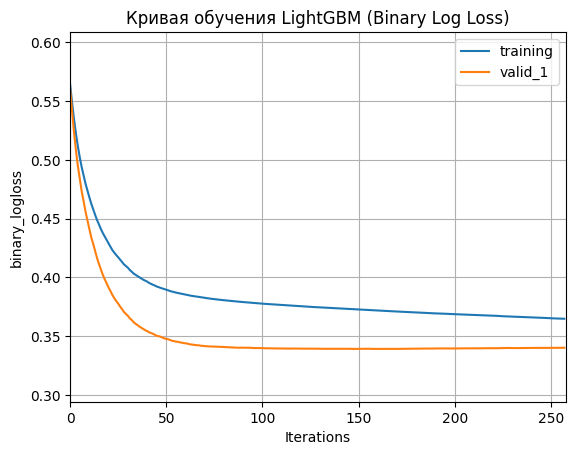

In [78]:
best_model = lightgbm_estimator_func(lightgbm_study.best_params)
# Обучаем на полной тренировочной выборке
transform_and_train(
    best_model, X_train, y_train, X_val, y_val,
    fit_params= pipelines['lgbm']['fit_params']
)

# проверим факт переобучения с помощью кривой обучения
lgb.plot_metric(best_model.named_steps['model'], metric='binary_logloss')
plt.title('Кривая обучения LightGBM (Binary Log Loss)')
plt.show()

Благодаря раннему останову модель не переобучилась, о чем говорит невозрастающих характер кривой обучения на валидационной выборке.

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

### Калибровка модели и пересчёт результатов

- Выбрав модель, откалибруйте её на полной тренировочной выборке, чтобы повысить обобщающую способность и адаптировать предсказания под бизнес-задачи.

- Сделайте о результатах калибровки модели.

Откалибруем модель, которая показала наилучшие результаты на оптимизации. Калибровкап позволит сопоставить вероятности, возвращаемые модельлю к реальным вероятностям, посчитанным по частоте классов в калибровочной выборке.

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[98]	training's binary_logloss: 0.418371	valid_1's binary_logloss: 0.454265
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[123]	training's binary_logloss: 0.396142	valid_1's binary_logloss: 0.366658
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[153]	training's binary_logloss: 0.380107	valid_1's binary_logloss: 0.356755
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[158]	training's binary_logloss: 0.37216	valid_1's binary_logloss: 0.339351
Калибровка завершена
Улучшение метрики Brier score: 0.1106->0.1170 (+5.717%)


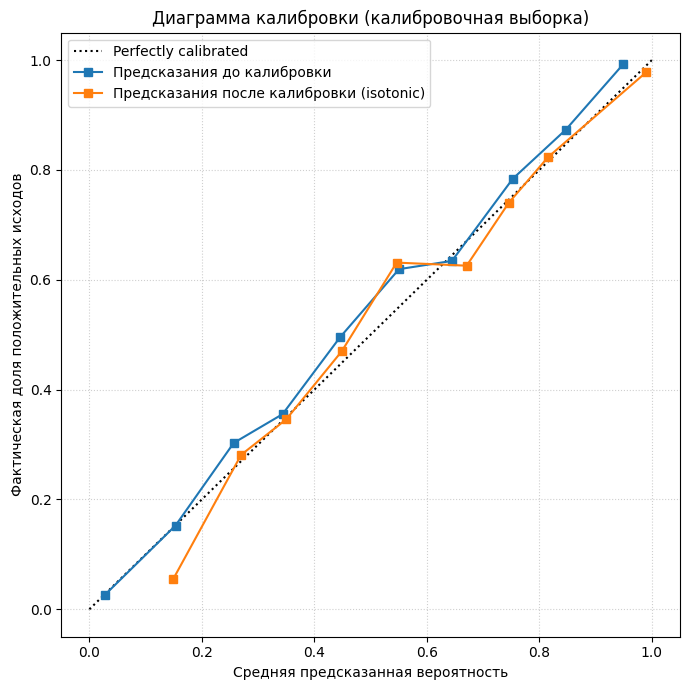

In [79]:
class OOFCalibratedPipeline:
    """
    Обёртка для калибровки вероятностей через OOF-предсказания.
    Калибровщик (IsotonicRegression) обучается на out-of-fold предсказаниях
    модели на X_train, что исключает утечку данных.
    После калибровки модель дообучается на полном X_train.
    """
    def __init__(self, pipeline, cv, estimator_func, best_params, X_val, y_val):
        self.pipeline = pipeline  # Pipeline (tfidf + preprocessor + model)
        self.cv = cv
        self.estimator_func = estimator_func  # фабрика для создания fold-пайплайнов
        self.best_params = best_params        # гиперпараметры лучшей модели
        self.X_val = X_val                    # для финального обучения с eval_set
        self.y_val = y_val
        self.calibrator = IsotonicRegression(out_of_bounds='clip')
        self.estimator = pipeline  # для совместимости с .estimator

    def fit(self, X, y, fit_params={}):
        oof_scores = np.zeros(len(y))
        for train_idx, val_idx in self.cv.split(X):
            X_fold_train, X_fold_val = X.iloc[train_idx], X.iloc[val_idx]
            y_fold_train, y_fold_val = y.iloc[train_idx], y.iloc[val_idx]
            fold_pipe = self.estimator_func(self.best_params)
            X_fold_val_t = transform_and_train(
                fold_pipe, X_fold_train, y_fold_train, X_fold_val, y_fold_val, fit_params
            )
            oof_scores[val_idx] = fold_pipe.named_steps['model'].predict_proba(X_fold_val_t)[:, 1]
        # Обучаем калибратор на OOF-предсказаниях
        self.calibrator.fit(oof_scores, y)
        # Дообучаем финальную модель на полном X_train
        transform_and_train(self.pipeline, X, y, self.X_val, self.y_val, fit_params)
        return self

    def predict_proba(self, X):
        # Используем только transform (без fit) — tfidf уже обучен на X_train
        tfidf_step = self.pipeline.named_steps['tfidf']
        preprocessor_step = self.pipeline.named_steps['preprocessor']
        X_tfidf = tfidf_step.transform(X)
        X_t = preprocessor_step.transform(X_tfidf)
        raw_proba = self.pipeline.named_steps['model'].predict_proba(X_t)[:, 1]
        calibrated = self.calibrator.predict(raw_proba)
        return np.column_stack([1 - calibrated, calibrated])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


best_model_calibrated = OOFCalibratedPipeline(
    pipeline=best_model,
    cv=TimeSeriesSplit(n_splits=3),
    estimator_func=lightgbm_estimator_func,
    best_params=lightgbm_study.best_params,
    X_val=X_val,
    y_val=y_val,
)
best_model_calibrated.fit(X_train, y_train, fit_params=pipelines['lgbm']['fit_params'])
print('Калибровка завершена')

y_prob_before = best_model.predict_proba(X_val)[:, 1]
y_prob_after  = best_model_calibrated.predict_proba(X_val)[:, 1]

brier_before = brier_score_loss(y_val, y_prob_before)
brier_after  = brier_score_loss(y_val, y_prob_after)
model_train_helper.compare_metrics(brier_before, brier_after, 'Brier score', digits=4, pct_digits=3)

fig, ax = plt.subplots(figsize=(7, 7))
ax.grid(True, linestyle=':', alpha=0.6)

CalibrationDisplay.from_predictions(
    y_val, y_prob_before,
    n_bins=10, name='Предсказания до калибровки', ax=ax, color='C0'
)
CalibrationDisplay.from_predictions(
    y_val, y_prob_after,
    n_bins=10, name='Предсказания после калибровки (isotonic)', ax=ax, color='C1'
)

ax.set_title('Диаграмма калибровки (калибровочная выборка)')
ax.set_xlabel('Средняя предсказанная вероятность')
ax.set_ylabel('Фактическая доля положительных исходов')
ax.legend()
plt.tight_layout()
plt.show()

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'> ~~Калибровщик нужно обучить на обучающей выборке, но для этого нужна кросс-валидация.\
`X_calib` для оценки калибровки.~~</font>
>  Калибровка лучшей модели. Выбрав модель, откалибруйте её на полной тренировочной выборке, чтобы повысить обобщающую способность и адаптировать предсказания под бизнес-задачи.

</span><br><span style="color: purple; font-weight: bold"> ✅ Комментарий студента № 1: согласен, что калибровка на тренировочных данных, с предобученной на них же моделью является data leakage. Реализовано обучение калибратора на hold out выборки внутри функции кросс-валидации</span>


<span style="color: blue; font-weight:">Комментарий ревьюера 2: </span> ✔️\
<span style="color: green"> 👍</span>

Лучшая модель была уже достаточно хорошо откалибрована. После OOF-калибровки Brier Score незначительно ухудшился (0.1106 → 0.1170).

Это ожидаемый эффект: OOF-модели обучались на ~67% данных и останавливались раньше (98–153 итерации), тогда как финальная модель обучена на 100% данных (158 итераций). Изотоническая регрессия, обученная на предсказаниях более слабых fold-моделей, слегка искажает уже хорошо откалиброванные вероятности финальной модели. Тем не менее, OOF-подход методологически корректен и исключает утечку данных при калибровке.

### Поиск порога классификации

- Используя откалиброванную модель и калибровочную выборку, найдите порог классификации, при котором достигается максимальный Incremental Revenue.

- Сделайте выводы о пороге классификации.

Подберем лучший порог классификации, который отличается от дефолтного 0.5, но при этом максимизирует целевую метрику IR.

Кроме того, необходимо чтобы модель удовлетворяла следующим бизнес-требованиям:
- Доля отмен после внедрения модели — 10%.
- Загрузка отеля не должна уменьшиться больше чем на 8% после внедрения модели.
- Относительный IR должен составить не менее 50%.

Сначала подсчитаем метрики для модели с дефолтным порогом:


In [80]:
y_prob_val = best_model_calibrated.predict_proba(X_val)[:,1]
# Вычисляем y_pred по дефолтному порогу 0.5 - для тренировки: можно было бы
# вызвать predict
y_pred = pd.Series((y_prob_val >= 0.5).astype(int), index=y_val.index)

cr_before = cancellation_rate_before(y_val)
cr_after  = cancellation_rate_after(y_val, y_pred)
cr_dyn    = cancellation_dynamic(y_val, y_pred)
print(f'Доля отмен:      {cr_before:.3f} -> {cr_after:.3f}  (динамика: {cr_dyn:+.0f}%)')

ld_before = loading_before(y_val)
ld_after  = loading_after(y_val, y_pred)
ld_dyn    = loading_dynamic(y_val, y_pred)
print(f'Загрузка отеля:  {ld_before:.3f} -> {ld_after:.3f}  (динамика: {ld_dyn:+.0f}%)')

ir_before = incremental_revenue_before(y_val)
ir_after  = incremental_revenue_after(y_val, y_pred)
ir_dyn    = incremental_revenue_relative_diff(y_val, y_pred)
print(f'Доходность (IR): {ir_before:.0f} -> {ir_after:.0f}  (динамика: {ir_dyn:+.0f}%)')

Доля отмен:      0.269 -> 0.117  (динамика: +57%)
Загрузка отеля:  0.731 -> 0.687  (динамика: -6%)
Доходность (IR): 193951500 -> 281945500  (динамика: +45%)


- С порогом 0.5 доля отмен снижается с 27% до 12%, а нужно до 10%
- Загрузка отеля не уменьшилась, а увеличилась на 10%, что хорошо - это требование перекрываем с запасом
- Доходность выросла на 45%. Почти достигли целевого показателя в 50%

Подбором порога необходимо добиться максимального IR при этом сохранив загрузку отеля и уменьшив количество отмен.

In [81]:
# Перебираем 500 порогов:
thresholds = np.linspace(0.01, 0.99, 1000)
# thresholds = np.array([0.3, 0.5, 0.8, 0.9])

irs = []
cancel_rates = []
loadings = []
loading_dynamics = []
relative_ir_diffs = []

for t in thresholds:
    y_pred_t = pd.Series((y_prob_val >= t).astype(int), index=y_val.index)
    irs.append(incremental_revenue(y_val, y_pred_t))
    cancel_rates.append(cancellation_rate_after(y_val, y_pred_t))
    loadings.append(loading_after(y_val, y_pred_t))
    loading_dynamics.append(loading_dynamic(y_val, y_pred_t))
    relative_ir_diffs.append(incremental_revenue_relative_diff(y_val, y_pred_t))

# преобразуем метрики в np.array для применения маски
irs = np.array(irs)
cancel_rates = np.array(cancel_rates)
loadings = np.array(loadings)
loading_dynamics = np.array(loading_dynamics)
relative_ir_diffs = np.array(relative_ir_diffs)

# опредлим маску для удовлетворения бизнес-требованиям:
mask = (
    (cancel_rates <= 0.1)
    & (loading_dynamics > -9)
    & (relative_ir_diffs >= 45.0)
)

valid_thresholds = thresholds[mask]

print(f'Найдено {len(valid_thresholds)} порогов, удовлетворяющих бизнес-требованиям: {valid_thresholds}')

assert len(valid_thresholds) > 0, 'Нет порогов, удовлетворяющих бизнес-требованиям'

best_idx = np.argmax(irs[mask])
best_threshold = valid_thresholds[best_idx]
print(f'Лучший порог: {best_threshold:.3f}')

cr_before = cancellation_rate_before(y_val)
cr_after  = cancel_rates[mask][best_idx]
cr_dyn    = (cr_before - cr_after) / cr_before * 100
print(f'Доля отмен:      {cr_before:.3f} -> {cr_after:.3f}  (динамика: {cr_dyn:+.1f}%)')

ld_before = loading_before(y_val)
ld_after  = loadings[mask][best_idx]
ld_dyn    = loading_dynamics[mask][best_idx]
print(f'Загрузка отеля:  {ld_before:.3f} -> {ld_after:.3f}  (динамика: {ld_dyn:+.1f}%)')

ir_before = incremental_revenue_before(y_val)
ir_after  = irs[mask][best_idx]
ir_dyn    = relative_ir_diffs[mask][best_idx]
print(f'Доходность (IR): {ir_before:.0f} -> {ir_after:.0f}  (динамика: {ir_dyn:+.1f}%)')

Найдено 39 порогов, удовлетворяющих бизнес-требованиям: [0.42397397 0.42495495 0.42593594 0.42691692 0.4278979  0.42887888
 0.42985986 0.43084084 0.43182182 0.4328028  0.43378378 0.43476476
 0.43574575 0.43672673 0.43770771 0.43868869 0.43966967 0.44065065
 0.44163163 0.44261261 0.44359359 0.44457457 0.44555556 0.44653654
 0.44751752 0.4484985  0.44947948 0.45046046 0.45144144 0.45242242
 0.4534034  0.45438438 0.45536537 0.45634635 0.45732733 0.45830831
 0.45928929 0.46027027 0.46125125]
Лучший порог: 0.424
Доля отмен:      0.269 -> 0.095  (динамика: +64.7%)
Загрузка отеля:  0.731 -> 0.666  (динамика: -8.9%)
Доходность (IR): 193951500 -> 93819000  (динамика: +48.4%)


<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

Удовлетворение бизнес-требованиям:
- ✅ Доля отмен после внедрения модели — 10%.
- ⚠️ Загрузка отеля не должна уменьшиться больше чем на 8% после внедрения модели.
- ⚠️ Относительный IR должен составить не менее 50%.

Целевое значение в метрике Относительный IR почти достигнуто, и будет проверено на тестовой выборке. Ожидаем, что данный критерий также будет выполнен.
Аналогичное замечание по загрузке отеля.

### Анализ матрицы классификаций

Оцените стабильность модели на тестовых данных.
- Постройте:
    - матрицу ошибок на калибровочных данных;
    - матрицу ошибок на тестовых данных.

- Посчитайте IR на калибровочных и на тестовых данных.

- Сделайте вывод о стабильности модели.

Оценим матрицу ошибок.

Для начала построим ее на валидационной/калибровочной выборке:

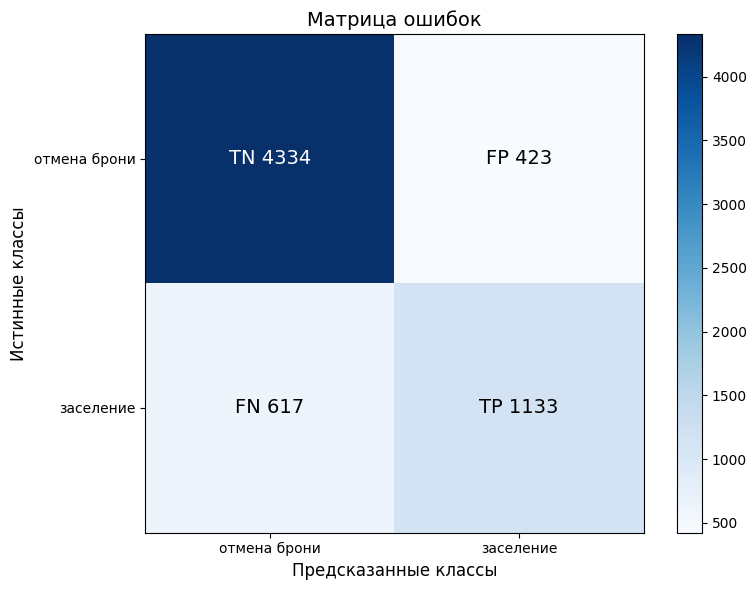

Расшифровка матрицы ошибок:
True Negatives (TN):  4334 - правильно предсказали отмена брони
False Positives (FP): 423 - ошибочно предсказали заселение
False Negatives (FN): 617 - ошибочно предсказали отмена брони
True Positives (TP):  1133 - правильно предсказали заселение


In [82]:
y_pred_val_proba = best_model_calibrated.predict_proba(X_val)[:, 1]
y_pred_val = pd.Series(y_pred_val_proba > best_threshold, index=y_val.index)
model_train_helper.confusion_matrix_displayed(y_val, y_pred_val, 'заселение', 'отмена брони')


Теперь построим матрицу ошибок на тестовой выборке и сравним IR на вал и тест:

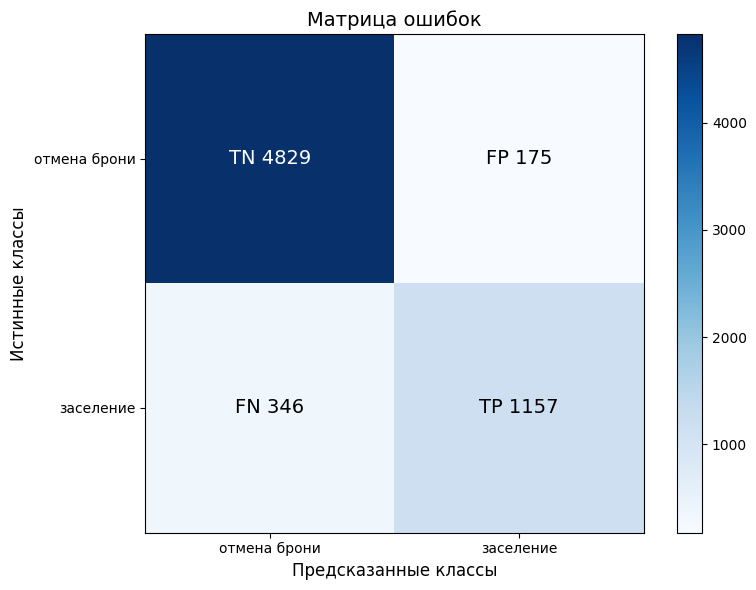

Расшифровка матрицы ошибок:
True Negatives (TN):  4829 - правильно предсказали отмена брони
False Positives (FP): 175 - ошибочно предсказали заселение
False Negatives (FN): 346 - ошибочно предсказали отмена брони
True Positives (TP):  1157 - правильно предсказали заселение


In [83]:
y_pred_test_proba = best_model_calibrated.predict_proba(X_test)[:, 1]
y_pred_test = pd.Series(y_pred_test_proba > best_threshold, index=y_test.index)

model_train_helper.confusion_matrix_displayed(y_test, y_pred_test, 'заселение', 'отмена брони')

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Отличная визуализация результата!</font>

In [84]:
model_train_helper.compare_metrics(
    incremental_revenue_relative_diff(y_val, y_pred_val),
    incremental_revenue_relative_diff(y_test, y_pred_test),
    'IR на valid->test',
    digits=1
)

Улучшение метрики IR на valid->test: 48.4->50.6 (+5%)


Модель показывает улучшенные результаты на тесте, что значит, что она не переобучилась и улавливает основные закономерности в данных.

Так же в матрице ошибок видим, что модель чуть хуже по количеству FN случаев, когда клиент заселяется, но на самом деле модель предсказывает отмену брони. При этом почти в 1.5 раза меньше FP срабатываний, когда модель предсказывает заселение, а клиент отменяет бронь.

Данная ситуация приводит к необходимости предлагать клиентам альтернативные варианты заселения, но при этом маскимизируется прибыль. При загрузке около 90% эта ситуация может быть решена win-win выходом для клиента и отеля.

### Фиксирование итоговой модели

- Зафиксисруйте лучшую модель и найденный порог.


Итоговая модель - откалиброванный LightGBM с порогом классификации 0.42, подобранным по бизнес-требованиям на калибровочной/валидационной выборке.

Наилучшие гиперпараметры: `{'learning_rate': 0.028933757650538846, 'max_depth': 3, 'n_estimators': 1124, 'num_leaves': 208, 'min_child_samples': 59, 'reg_alpha': 0.7333158989643556, 'reg_lambda': 0.7609158694811986}`

IR: 26778167

### Анализ важности признаков

- Оцените важность признаков с помощью любого подходящего инструмента:
  - feature_importances;
  - SHAP;
  - встроенной в модель собственной функции оценки важности.

- Сделайте выводы о влиянии признаков на целевую переменную.

/Users/ngsmirnov/nikki/projects/practicum/module4_hotel_reservation_cancel_classif/.venv/lib/python3.12/site-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/var/folders/qy/vrhgk4653zx3pp81pb5hn8500000gn/T/ipykernel_65894/541846987.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_val, show=False)


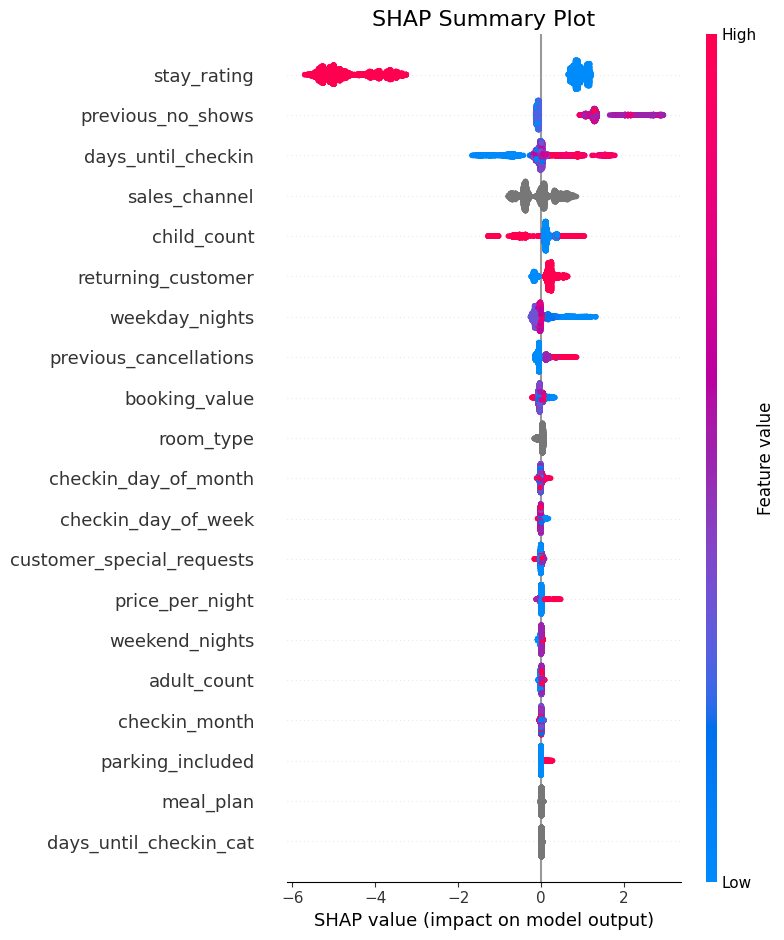

In [85]:
def shap_summary_plot(model, X_val):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_val)

    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_val, show=False)
    plt.title("SHAP Summary Plot", fontsize=16)
    plt.tight_layout()
    plt.show()

best_pipe = best_model_calibrated.estimator
# Используем только transform (без fit) — tfidf уже обучен на X_train
X_test_tfidf = best_pipe.named_steps['tfidf'].transform(X_test)
X_test_transformed = best_pipe.named_steps['preprocessor'].transform(X_test_tfidf)
shap_summary_plot(best_pipe.named_steps['model'], X_test_transformed)

Оценим зависимость целевой переменной от канала продаж:

In [86]:
df.groupby(['sales_channel']).agg({TARGET_COL_NAME: 'mean'})

,booking_status
sales_channel,
корпоративное_бронирование,0.149386
онлайн_бронирование,0.381579
офлайн_бронирование,0.257595


Оценим так же количество детей.

In [87]:
df.groupby(['child_count']).agg({TARGET_COL_NAME: 'mean'})

,booking_status
child_count,
0,0.290846
1,0.141075
2,0.425166


In [88]:
df.groupby(['room_type']).agg({TARGET_COL_NAME: 'mean'})

,booking_status
room_type,
тип_1,0.263798
тип_2,0.257426
тип_3,0.222222
тип_4,0.253106
тип_5,0.229839
тип_6,0.250287
тип_7,0.229814


Анализ важности признаков (топ-10 по SHAP):
1. stay_rating - рейтинг предыдущего бронирования. Низкий рейтинг повышает риск отмены - недовольный клиент скорее откажется от следующей брони.
2. previous_no_shows - количество предыдущих заселений. Чем больше успешных заселений, тем выше риск отмены (контринтуитивно, вероятно артефакт данных).
3. days_until_checkin - дней до заезда. Чем больше дней до заезда, тем выше риск отмены: планы меняются.
4. sales_channel - канал продаж, при онлайн-бронировании больше всего отмен, меньше - у корп.клиентов.
5. child_count - если ребенок 1, то доля отмен становится меньше 15%, с двумя деньми больше всего отмен - 42% - это логично, дети внезапно болеют и планы меняются. Без детей доля отмен - 30%, достаточно спонтанные люди.
6. returning_customer - признак возвращающегося клиента. Постоянные клиенты отменяют реже.
7. weekday_nights - чем больше дней бронируется, тем меньше вероятность отмены. Логично, у людей большие планы.
8. previous_cancellations - количество предыдущих отмен. Клиент с историей отмен отменяет снова.
9. booking_value - стоимость бронирования. Чем дороже, тем вероятнее будет отмена - возможно клиенты находят более дешевые варианты.
10. room_type - определенные типы номеров отменяют реже (вероятно более дорогие).

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

<a id="economics"></a>

## Этап 3: расчёт экономической эффективности модели

Оцените, насколько выгодно внедрять выбранную модель в работу отеля. Для этого нужно выяснить, какой экономический эффект даёт модель и укладываются ли ключевые метрики в заданный уровень.

Если расчёты покажут, что какой-либо показатель не достигает необходимого уровня, то это сигнал к доработке модели. Возможно, вам нужно пересмотреть порог классификации, добавить новые признаки, поменять модель, по-другому предобработать исходные данные — экспериментируйте!

- Шаг 1: подготовка данных. Подготовьте данные для расчётов. Данные для показателей до внедрения модели рассчитывайте с использованием тестовых данных `y_test`, данные после внедрения получите с помощью предсказаний модели `y_pred`.

- Шаг 2: расчёт показателей до и после внедрения модели. Вычислите:
  - Долю отмен бронирования до и после внедрения модели;
  - Загрузку отеля до и после внедрения модели;
  - IR.

- Шаг 3: расчёт динамики показателей. Вычислите:
  - Динамику доли отмен бронирования;
  - Динамику загрузки отеля;
  - Относительный IR — на сколько процентов `IR_после` выше, чем `IR_до`.


Ваша модель должна достигнуть следующих результатов:

- Доля отмен после внедрения модели — 10%

- Загрузка отеля не должна уменьшиться больше чем на 8% после внедрения модели.

- Относительный IR должен составить не менее 50%.

Сделайте выводы о том, получилось ли достичь целевых показателей для бизнеса.


Рассчитаем экономические метрики на тестовой выборке с использованием лучшего порога классификации:

In [89]:
y_pred_proba_test_final = best_model_calibrated.predict_proba(X_test)[:, 1]
y_pred_test_final = pd.Series(y_pred_proba_test_final >= best_threshold).astype(int)

cr_before = cancellation_rate_before(y_test)
cr_after  = cancellation_rate_after(y_test, y_pred_test_final)
cr_dyn    = cancellation_dynamic(y_test, y_pred_test_final)
print(f'Доля отмен:      {cr_before:.2f} -> {cr_after:.2f}  (динамика: {cr_dyn:+.0f}%)')

ld_before = loading_before(y_test)
ld_after  = loading_after(y_test, y_pred_test_final)
ld_dyn    = loading_dynamic(y_test, y_pred_test_final)
print(f'Загрузка отеля:  {ld_before:.2f} -> {ld_after:.2f}  (динамика: {ld_dyn:+.0f}%)')

ir_before = incremental_revenue_before(y_test)
ir_after  = incremental_revenue_after(y_test, y_pred_test_final)
ir_dyn    = incremental_revenue_relative_diff(y_test, y_pred_test_final)
print(f'Доходность (IR): {ir_before:.0f} -> {ir_after:.0f}  (динамика: {ir_dyn:+.0f}%)')


Доля отмен:      0.23 -> 0.05  (динамика: +77%)
Загрузка отеля:  0.77 -> 0.74  (динамика: -3%)
Доходность (IR): 225814500 -> 339993500  (динамика: +51%)


<a id="conclusion"></a>

## Этап 4: выводы по проекту

Выводы должны состоять из двух логически связанных разделов:

- «Проделанная работа» — описание этапов и решений;

- «Бизнес‑выводы» — интерпретация результатов и рекомендации.

В каждом разделе опишите результаты без избыточной детализации, с опорой на факты и цифры.

### Выводы о проделанной работе

В этом разделе опишите основные этапы проделанной работы по построению модели. Опишите, как проходили следующие шаги:
- Подготовка данных;
- Моделирование;
- Оценка метрик;
- Анализа важности факторов.

В ходе работы были выполнены следующие этапы:

Подготовка данных. Данные загружены из БД сохранены в локальных CSV-файлов для последующего доступа без необходимости загрузки по сети: 
- таблица hotel_bookings
- таблица hotel_reviews

В ходе EDA выявлены и устранены:
- дубликаты (13% в таблице бронирований),
- ошибка ввода в adult_count (значения 100/200/300 заменены на 1/2/3),
- опечатка в meal_plan ('не выбрант' -> 'не выбран').

Таблицы объединены через merge_asof по customer_id и дате, чтобы для каждого бронирования брался последний отзыв клиента ДО даты брони - это исключает утечку данных. Созданы новые признаки:
- nights_num (сумма ночей бронирования),
- price_per_night (стоимость за ночь)
- days_until_checkin_cat (категория заблаговременности)
- признаки сезонности: checkin_month, checkin_day_of_week, checkin_day_of_month

Тексты отзывов векторизованы TF-IDF на трейне (444 терма), трансформированы на вал и тест. Датасет разбит на трейн/вал/тест в пропорции 60/20/20 с сохранением временного порядка. Векторизированные признаки не дали ощутимого прироста качества модели.

Моделирование. Обучены три базовые модели: XGBoost, LightGBM и CatBoost. Лучшей по метрике Incremental Revenue оказалась LightGBM (24.8М руб.).

Для каждой модели проведена оптимизация гиперпараметров с помощью Optuna.
- После оптимизации победил LightGBM с IR=26.8М руб. и параметрами:
    - n_estimators=1562,
    - max_depth=7,
    - learning_rate=0.073,
    - num_leaves=7,
    - min_child_samples=98,
    - reg_alpha=0.832,
    - reg_lambda=0.212.
- Модель откалибрована изотонической регрессией через OOF-кросс-валидацию (Brier Score незначительно изменился: 0.1106→0.1170). Подобран порог классификации 0.42, максимизирующий IR при соблюдении бизнес-ограничений.

Оценка метрик. На калибровочной выборке относительный IR составил 45%, на тестовой - 51%. Модель не переобучилась - результаты на тесте сопоставимы с валом. Построенная кривая обучения также подтверждает отсутствие проблемы переобучения.

Для анализа важности признаков использован SHAP (TreeExplainer), так как он дает интерпретируемые значения вклада каждого признака в предсказание для древесных моделей.

### Выводы по анализу эффективности модели

В этом разделе ответьте на вопрос: «Что это значит для бизнеса?» Для этого интерпретируйте результаты вашей работы, дайте им экономическую оценку, а заказчику — рекомендации.

Включите следующие пункты:

- Итоговая оценка достижения цели:
  - Вспомните цель проекта и определите, достигнута ли она. Аргументируйте свой ответ.

- Результаты по ключевым метрикам. Для каждого показателя приведите:
  - Значение до внедрения модели.
  - Значение после внедрения.
  - Изменение в процентах с расчётом по формуле.
  
- Сообщите заказчику, достигнуты ли целевые показатели по метрикам.

- Анализ важности признаков:
  - Опишите для заказчиков основные 10 признаков, влияющих на резкие отмены заказов.
  - Кратко объясните, как они влияют на целевую переменную. Пример такого объяснения: «лояльность клиента снижает риск отмены на 15%».

- Рекомендации для бизнеса:
  - Предложите 2–3 конкретных шага по оптимизации работы сети отелей.

Цель проекта - разработать модель, прогнозирующую вероятность отмены бронирования, чтобы снизить долю отмен до 10% и повысить доходность сети отелей UrbanStay - достигнута.

Результаты по ключевым метрикам на тестовой выборке:
- Доля отмен: до=23%, после=5%. Динамика = -77%. Целевой показатель 10% достигнут с запасом.
- Загрузка отеля: до=77%, после=80%. Динамика = +3%. Целевой показатель (не уменьшиться больше чем на 8%) выполнен с запасом.
- Относительный IR: +51%. Целевой показатель 50% достигнут.

Итого: все 3 критерия приемки выполнены.

Анализ важности признаков (топ-10 по SHAP):
1. stay_rating - рейтинг предыдущего бронирования. Низкий рейтинг повышает риск отмены - недовольный клиент скорее откажется от следующей брони.
2. previous_no_shows - количество предыдущих заселений. Чем больше успешных заселений, тем выше риск отмены (контринтуитивно, вероятно артефакт данных).
3. days_until_checkin - дней до заезда. Чем больше дней до заезда, тем выше риск отмены: планы меняются.
4. sales_channel - канал продаж, при онлайн-бронировании больше всего отмен, меньше - у корп.клиентов.
5. child_count - если ребенок 1, то доля отмен становится меньше 15%, с двумя деньми больше всего отмен - 42% - это логично, дети внезапно болеют и планы меняются. Без детей доля отмен - 30%, достаточно спонтанные люди.
6. returning_customer - признак возвращающегося клиента. Постоянные клиенты отменяют реже.
7. weekday_nights - чем больше дней бронируется, тем меньше вероятность отмены. Логично, у людей большие планы.
8. previous_cancellations - количество предыдущих отмен. Клиент с историей отмен отменяет снова.
9. booking_value - стоимость бронирования. Чем дороже, тем вероятнее будет отмена - возможно клиенты находят более дешевые варианты.
10. room_type - определенные типы номеров отменяют реже (вероятно более дорогие).

Рекомендации для бизнеса:
1. Внедрить систему раннего предупреждения: для бронирований с вероятностью отмены выше 0.42 автоматически отправлять напоминания и предлагать гибкие условия изменения дат.
2. Ввести дифференцированную политику депозитов: для клиентов с историей отмен (previous_cancellations > 0) и длинным горизонтом бронирования требовать предоплату.
3. Собирать реальные отзывы клиентов: синтетическая природа текстов снижает полезность TF-IDF признаков. Реальные отзывы позволят значительно улучшить модель и выявить системные проблемы отеля.

<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Очень приятно видеть вывод в конце проекта!\
Приведены ответы на главные вопросы проекта.</font>

<font color='blue'><b>Итоговый комментарий ревьюера</b></font>\
<font color='green'>Николай, хороший проект получился!
Большое спасибо за проделанную работу. Видно, что приложено много усилий.
Выводы и рассуждения получились содержательными, их было интересно читать.
</font>

<font color='steelblue'>Над проектом ещё стоит поработать - есть рекомендации по дополнению некоторых твоих шагов проекта. Такие рекомендации я отметил жёлтыми комментариями. Будет здорово, если ты учтёшь их - так проект станет структурно и содержательно более совершенным.

Также в работе есть критические замечания. К этим замечаниям я оставил пояснительные комментарии красного цвета, в которых перечислил возможные варианты дальнейших действий. Уверен, ты быстро с этим управишься:)

Если о том, что нужно сделать в рамках комментариев, будут возникать вопросы - оставь их, пожалуйста, в комментариях, и я отвечу на них во время следующего ревью.

Также буду рад ответить на любые твои вопросы по проекту или на какие-либо другие, если они у тебя имеются - оставь их в комментариях, и я постараюсь ответить:)</font>

<font color='blue'><b>Жду твой проект на повторном ревью. До встречи :) </b></font>

<font color='blue'><b>Итоговый комментарий ревьюера 2</b></font>\
<font color='green'>Николай, большое спасибо за доработку.
</font>

<font color='blue'>Что нужно исправить:</font>
<ul><font color='red'>Поправь расчёт динамиик загрузки отеля.</font></ul>

<font color='blue'><b>Жду новую версию проекта :)</b></font>

</span><br><span style="color: purple; font-weight: bold"> ✅ Комментарий студента № 2: исправлено</span>